In [25]:
#!/usr/bin/env python3
"""
GCE 12yr Analysis Pipeline v8.2 — Cholis+2022 Reproduction
=================================================================

⭐⭐⭐ v8.2 결정적 수정: Cholis Zenodo 단위 변환 ⭐⭐⭐

[v6/v7/v8/v8.1의 진짜 systematic error 발견]

  Cholis ZENODO README가 명시:
    "Folder GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg ...
     Units are in GeV cm^-2 s^-1 sr^-1 i.e. E^2*dPhi/dE"

  즉 Zenodo의 pi0/bremss/ICS Map_flux_*.fits 파일은
    E²·dPhi/dE [GeV/cm²/s/sr] 단위!

  그런데 Fermi MapCubeFunction은 dPhi/dE [ph/cm²/s/MeV/sr] 형식을 expect.

  v6~v8.1까지 우리는 Zenodo flux를 그대로 MapCube로 저장 (변환 없이)
  → fit이 c_gas, c_ics를 ~0.001로 보내서 보상
  → GCE template이 모든 inner Galaxy emission을 흡수하도록 강요됨
  → systematic 0.755 ratio + spectral shape 왜곡

[Sanghwan 검증 (결정적 증거)]

  진단 결과:
    Sanghwan max @ 1 GeV = 2.532e-07
    Zenodo  max @ 1 GeV = 2.021e-04
    Sanghwan / Zenodo   = 1.253e-03 = 1 / (E_GeV² × 1000)
    E_GeV = 0.8935 (1 GeV bin center)
  
  → Sanghwan이 정확히 다음 변환을 적용했다는 확정 증거.

[v8.2의 정확한 해결책]

  Cell 4 (convert_zenodo_to_mapcube_native)에 단위 변환 추가:
  
    dN/dE [ph/cm²/s/MeV/sr] = (E²·dPhi/dE [GeV/cm²/s/sr]) / (E_GeV² × 1000)
  
  코드:
    E_GeV = src_energies / 1000.0  # MeV → GeV
    conversion_factor = 1.0 / (E_GeV ** 2 * 1000.0)
    flux_dnde = flux * conversion_factor[:, np.newaxis, np.newaxis]


[이전 v6/v7/v8/v8.1 fix들이 효과 없었던 이유]

  - NFW² normalization (v7): SED에 무영향 (cancellation)
  - MapCube 38-node grid (v8): grid은 맞았지만 absolute scale은 잘못됨
  - EDISP (v8.1): isotropic/bubble만 영향, GDE는 동일
  - 모두 GDE template absolute scale을 고치지 못했음

  하지만 이 변경들 자체는 모두 valid한 개선이고 v8.2에 포함됨.


[v8.1 → v8.2 마이그레이션]

  단위 변환은 MapCube 단계에 적용되므로:
  
    rm -rf MapCubes/                          # 단위 잘못된 이전 cube
    rm -rf Source_Maps Source_Maps_NoConvol   # 그 cube 기반 srcmap
    rm -rf Component_Maps Component_Maps_NoConvol  # 그 srcmap 기반 component
    rm -f GCE_results_v8_1.pkl                # v8.1 결과
  
  Allsky_*, ltcube, ccube, expcube, masks 등은 보존.


[v7 이전의 변경사항 — 모두 유지]
  ✅ NFW² 템플릿 ALL-SKY 정규화 (Cell 5)
  ✅ MapCube 38 nodes native grid 보존 (Cell 4) — v8 추가
  ✅ EDISP FileFunction (Cell 6) — v8.1 추가
  ✅ Isotropic 제약 = Ackermann+2015 Table 3 (Model A)
  ✅ Section 6.5: bubble/iso constraint 파일
  ✅ MCMC chi² priors (Cholis Eq. 13)
  ✅ gtsrcmaps × 2 (convol=yes/no)
  ✅ 80-Model envelope (Cell 16)


[기대 결과 (v8.2)]

  - c_gas, c_ics 평균: ~1.0 (정상)
  - Pipeline / Zenodo Model X ratio: ~1.0 (이전 0.755)
  - 우리 best fit이 Cholis best (XLIX 또는 그 근처) 모델로 수렴
  - 80-model envelope이 정상 spread를 가짐 (음수 값 사라지거나 줄어듦)


[검증 우선순위]

  1. Cell 4 출력에서 "v8.2 검증" 라인 확인
     - pi0 max @ 1 GeV이 ~2.5e-07 (Sanghwan 일치)이어야 함
  
  2. Cell 11/12 진단:
     - c_gas, c_ics 평균이 ~1.0
  
  3. Cell 14:
     - Pipeline Model X / Zenodo Model X ratio ≈ 1.0
"""


'\nGCE 12yr Analysis Pipeline v8.2 — Cholis+2022 Reproduction\n=================================================================\n\n⭐⭐⭐ v8.2 결정적 수정: Cholis Zenodo 단위 변환 ⭐⭐⭐\n\n[v6/v7/v8/v8.1의 진짜 systematic error 발견]\n\n  Cholis ZENODO README가 명시:\n    "Folder GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg ...\n     Units are in GeV cm^-2 s^-1 sr^-1 i.e. E^2*dPhi/dE"\n\n  즉 Zenodo의 pi0/bremss/ICS Map_flux_*.fits 파일은\n    E²·dPhi/dE [GeV/cm²/s/sr] 단위!\n\n  그런데 Fermi MapCubeFunction은 dPhi/dE [ph/cm²/s/MeV/sr] 형식을 expect.\n\n  v6~v8.1까지 우리는 Zenodo flux를 그대로 MapCube로 저장 (변환 없이)\n  → fit이 c_gas, c_ics를 ~0.001로 보내서 보상\n  → GCE template이 모든 inner Galaxy emission을 흡수하도록 강요됨\n  → systematic 0.755 ratio + spectral shape 왜곡\n\n[Sanghwan 검증 (결정적 증거)]\n\n  진단 결과:\n    Sanghwan max @ 1 GeV = 2.532e-07\n    Zenodo  max @ 1 GeV = 2.021e-04\n    Sanghwan / Zenodo   = 1.253e-03 = 1 / (E_GeV² × 1000)\n    E_GeV = 0.8935 (1 GeV bin center)\n\n  → Sanghwan이 정확히 다음 변환을 적용했다는 확정 증거.\n\n[v8.2의 정확한 해결책]\n\n  Cell 4 (co

In [26]:
# %% ══════════════════════════════════════════════════════════
# SECTION 0: 임포트 및 설정
# ══════════════════════════════════════════════════════════════
import numpy as np
import os, glob, subprocess, time, pickle
import xml.etree.ElementTree as ET
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ── 경로 설정 (환경에 맞게 확인) ─────────────────────────────
WORK_DIR    = '/home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce'
DATA_DIR    = '/home/haebarg/GCE-Chi-square-fitting/GCE_12yr_data/'
GDE_DIR     = '/home/haebarg/GCE-Chi-square-fitting/GCE_TEMPLATES_FILES_v3/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/'
NAMING_FILE = '/home/haebarg/GCE-Chi-square-fitting/GCE_TEMPLATES_FILES_v3/NAMING_CONVENTION_OF_DIFFUSE_EMISSION_MODELS.dat'

# ── 데이터 파일 ──────────────────────────────────────────────
SC_FILE  = os.path.join(DATA_DIR, 'L2603311558186615_SC00.fits')
PH_FILES = [os.path.join(DATA_DIR, f'L2603311558186615_PH0{i}.fits') for i in range(5)]
ISO_SPECTRUM_FILE = os.path.join(DATA_DIR, 'iso_P8R3_CLEAN_V3_v1.txt')

os.makedirs(WORK_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════
# 핵심 분석 파라미터 (논문 Table III / IV와 완전 일치)
# ══════════════════════════════════════════════════════════════
EVCLASS       = 256          # CLEAN
EVTYPE        = 1            # FRONT-only
IRFS          = 'P8R3_CLEAN_V3'
ZMAX          = 100
ROCK_ANGLE    = 52
PIXEL_SIZE    = 0.1          # degrees
NX_FULL, NY_FULL = 600, 600  # 60°×60° (gtsrcmaps용)
NX_FIT,  NY_FIT  = 400, 400  # 40°×40° (피팅 영역)
OFFSET = (NX_FULL - NX_FIT) // 2  # 100

# ── 에너지 비닝 (논문 Table III 14 bins) ────────────────────
ENERGY_EDGES_GEV = np.array([
    0.275, 0.357, 0.464, 0.603, 0.784, 1.02, 1.32, 1.72,
    2.24, 2.91, 3.78, 4.91, 10.8, 23.7, 51.9
])
N_ENERGY_BINS      = len(ENERGY_EDGES_GEV) - 1
ENERGY_CENTERS_GEV = np.sqrt(ENERGY_EDGES_GEV[:-1] * ENERGY_EDGES_GEV[1:])
ENERGY_WIDTHS_GEV  = ENERGY_EDGES_GEV[1:] - ENERGY_EDGES_GEV[:-1]
ENERGY_EDGES_MEV   = ENERGY_EDGES_GEV * 1000.0
ENERGY_CENTERS_MEV = ENERGY_CENTERS_GEV * 1000.0

PIXEL_SR = (PIXEL_SIZE * np.pi / 180.0) ** 2

# ── ROI 물리 상수 (레퍼런스와 동일) ──────────────────────────
SR_ROI = 0.4288213187542626  # 40°×40° disk-masked ROI solid angle [sr]

# ── 디렉토리 이름들 (v5와 분리) ──────────────────────────────
XML_DIR            = os.path.join(WORK_DIR, 'XML_models')
SRCMAP_DIR         = os.path.join(WORK_DIR, 'Source_Maps')            # convol=yes
SRCMAP_DIR_NC      = os.path.join(WORK_DIR, 'Source_Maps_NoConvol')   # convol=no
COMPMAP_DIR        = os.path.join(WORK_DIR, 'Component_Maps')         # convol=yes
COMPMAP_DIR_NC     = os.path.join(WORK_DIR, 'Component_Maps_NoConvol')# convol=no
MAPCUBE_DIR        = os.path.join(WORK_DIR, 'MapCubes')
for _d in [XML_DIR, SRCMAP_DIR, SRCMAP_DIR_NC, COMPMAP_DIR, COMPMAP_DIR_NC, MAPCUBE_DIR]:
    os.makedirs(_d, exist_ok=True)

print(f"에너지 범위: {ENERGY_EDGES_GEV[0]:.3f} – {ENERGY_EDGES_GEV[-1]:.1f} GeV ({N_ENERGY_BINS} bins)")
print(f"IRFs: {IRFS}, evclass={EVCLASS}, evtype={EVTYPE}")
print(f"맵 크기: {NX_FULL}×{NY_FULL} (피팅 영역: {NX_FIT}×{NY_FIT})")
print(f"Ω_pixel (flat) = {PIXEL_SR:.4e} sr")
print(f"SR_ROI (ROI 총 solid angle) = {SR_ROI:.6f} sr")


에너지 범위: 0.275 – 51.9 GeV (14 bins)
IRFs: P8R3_CLEAN_V3, evclass=256, evtype=1
맵 크기: 600×600 (피팅 영역: 400×400)
Ω_pixel (flat) = 3.0462e-06 sr
SR_ROI (ROI 총 solid angle) = 0.428821 sr


In [27]:
# %% ══════════════════════════════════════════════════════════
# SECTION 1: RAW DATA 전처리 (gtselect → gtmktime)
# ⚠️ 이미 CLEAN/FRONT 데이터가 처리되어 있으면 자동으로 건너뜀
# ══════════════════════════════════════════════════════════════
events_list = os.path.join(WORK_DIR, 'events_list.txt')
with open(events_list, 'w') as f:
    for ph in PH_FILES:
        f.write(ph + '\n')

filtered_file = os.path.join(WORK_DIR, 'GCE_12yr_filtered.fits')
gti_file      = os.path.join(WORK_DIR, 'GCE_12yr_gti.fits')

# ── 1a. gtselect ──────────────────────────────────────────
if not os.path.exists(filtered_file):
    cmd = (
        f"gtselect "
        f"infile=@{events_list} "
        f"outfile={filtered_file} "
        f"ra=INDEF dec=INDEF rad=INDEF "
        f"emin=100 emax=1000000 "
        f"zmax={ZMAX} "
        f"evclass={EVCLASS} "
        f"evtype={EVTYPE} "
        f"tmin=INDEF tmax=INDEF "
        f"chatter=2 mode=ql"
    )
    print("1a. gtselect 실행 중... (CLEAN + FRONT)")
    subprocess.run(cmd, shell=True, check=True)
    print(f"  ✅ {filtered_file}")
else:
    print(f"1a. gtselect 이미 완료: {filtered_file}")

# ── 1b. gtmktime ──────────────────────────────────────────
if not os.path.exists(gti_file):
    filter_expr = f'DATA_QUAL==1 && LAT_CONFIG==1 && ABS(ROCK_ANGLE)<{ROCK_ANGLE}'
    cmd = (
        f"gtmktime "
        f"scfile={SC_FILE} "
        f'filter="{filter_expr}" '
        f"roicut=no "
        f"evfile={filtered_file} "
        f"outfile={gti_file} "
        f"chatter=2 mode=ql"
    )
    print("1b. gtmktime 실행 중...")
    subprocess.run(cmd, shell=True, check=True)
    print(f"  ✅ {gti_file}")
else:
    print(f"1b. gtmktime 이미 완료: {gti_file}")


1a. gtselect 이미 완료: /home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/GCE_12yr_filtered.fits
1b. gtmktime 이미 완료: /home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/GCE_12yr_gti.fits


In [28]:
# %% ══════════════════════════════════════════════════════════
# SECTION 2: 에너지 빈 정의 + BINNED DATA PRODUCTS (14 bins)
# ══════════════════════════════════════════════════════════════
bin_def_txt    = os.path.join(WORK_DIR, 'bin_definitions.txt')
bin_def_fits   = os.path.join(WORK_DIR, 'bin_definitions.fits')
ccube_file     = os.path.join(WORK_DIR, 'GCE_12yr_ccube.fits')
ltcube_file    = os.path.join(WORK_DIR, 'GCE_12yr_ltcube.fits')
expcube_center = os.path.join(WORK_DIR, 'GCE_12yr_expcube_center.fits')
expcube_edge   = os.path.join(WORK_DIR, 'GCE_12yr_expcube_edge.fits')

# ── 2a. gtbindef ──────────────────────────────────────────
with open(bin_def_txt, 'w') as f:
    for i in range(len(ENERGY_EDGES_GEV) - 1):
        f.write(f"{ENERGY_EDGES_GEV[i]:.6f} {ENERGY_EDGES_GEV[i+1]:.6f}\n")

if not os.path.exists(bin_def_fits):
    cmd = (
        f"gtbindef bintype=E "
        f"binfile={bin_def_txt} "
        f"outfile={bin_def_fits} "
        f"energyunits=GeV chatter=2 mode=ql"
    )
    print("2a. gtbindef 실행 중...")
    subprocess.run(cmd, shell=True, check=True)
    print(f"  ✅ {bin_def_fits} ({N_ENERGY_BINS} bins)")

# ── 2b. CCUBE ─────────────────────────────────────────────
if not os.path.exists(ccube_file):
    cmd = (
        f"gtbin evfile={gti_file} scfile=NONE "
        f"outfile={ccube_file} algorithm=CCUBE "
        f"nxpix={NX_FULL} nypix={NY_FULL} binsz={PIXEL_SIZE} "
        f"coordsys=GAL xref=0.0 yref=0.0 axisrot=0.0 proj=CAR "
        f"ebinalg=FILE ebinfile={bin_def_fits} mode=ql"
    )
    print(f"2b. CCUBE 생성 중 ({NX_FULL}×{NY_FULL}, {N_ENERGY_BINS} bins)...")
    subprocess.run(cmd, shell=True, check=True)
    print(f"  ✅ {ccube_file}")
else:
    print(f"2b. CCUBE 이미 존재: {ccube_file}")

# ── 2c. LTCube ─────────────────────────────────────────────
if not os.path.exists(ltcube_file):
    cmd = (
        f"gtltcube evfile={gti_file} scfile={SC_FILE} "
        f"outfile={ltcube_file} dcostheta=0.025 binsz=1 zmax={ZMAX} mode=ql"
    )
    print("2c. LTCube 생성 중 (수 시간 소요)...")
    subprocess.run(cmd, shell=True, check=True)
    print(f"  ✅ {ltcube_file}")
else:
    print(f"2c. LTCube 이미 존재: {ltcube_file}")

# ── 2d. Exposure Map CENTER ────────────────────────────────
if not os.path.exists(expcube_center):
    cmd = (
        f"gtexpcube2 infile={ltcube_file} cmap=none "
        f"outfile={expcube_center} irfs={IRFS} evtype={EVTYPE} "
        f"nxpix={NX_FULL} nypix={NY_FULL} binsz={PIXEL_SIZE} "
        f"coordsys=GAL xref=0 yref=0 axisrot=0.0 proj=CAR "
        f"ebinalg=FILE ebinfile={bin_def_fits} "
        f"bincalc=CENTER chatter=2 mode=ql"
    )
    print("2d. Exposure Map (CENTER) 생성 중...")
    subprocess.run(cmd, shell=True, check=True)
    print(f"  ✅ {expcube_center}")
else:
    print(f"2d. ExpCube CENTER 이미 존재: {expcube_center}")

# ── 2e. Exposure Map EDGE (all-sky, gtsrcmaps용) ──────────
if not os.path.exists(expcube_edge):
    cmd = (
        f"gtexpcube2 infile={ltcube_file} cmap=none "
        f"outfile={expcube_edge} irfs={IRFS} evtype={EVTYPE} "
        f"nxpix=3600 nypix=1800 binsz=0.1 "
        f"coordsys=GAL xref=0 yref=0 axisrot=0.0 proj=CAR "
        f"ebinalg=FILE ebinfile={bin_def_fits} "
        f"bincalc=EDGE chatter=2 mode=ql"
    )
    print("2e. Exposure Map (EDGE, all-sky) 생성 중...")
    subprocess.run(cmd, shell=True, check=True)
    print(f"  ✅ {expcube_edge}")
else:
    print(f"2e. ExpCube EDGE 이미 존재: {expcube_edge}")


2b. CCUBE 이미 존재: /home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/GCE_12yr_ccube.fits
2c. LTCube 이미 존재: /home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/GCE_12yr_ltcube.fits
2d. ExpCube CENTER 이미 존재: /home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/GCE_12yr_expcube_center.fits
2e. ExpCube EDGE 이미 존재: /home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/GCE_12yr_expcube_edge.fits


In [29]:
# %% ══════════════════════════════════════════════════════════
# SECTION 3: GDE MapCube 변환 + Isotropic MapCube 생성
# ══════════════════════════════════════════════════════════════
# ⭐⭐⭐ v8.2 결정적 수정: Cholis Zenodo 단위 변환 ⭐⭐⭐
#
# [v6/v7/v8/v8.1의 진짜 시스템 오류]
# Cholis Zenodo README가 명시:
#   "Folder GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg ...
#    Units are in GeV cm^-2 s^-1 sr^-1 i.e. E^2*dPhi/dE"
# 
# 즉 Zenodo의 pi0/bremss/ICS Map_flux_*.fits는 E²·dPhi/dE 단위 [GeV/cm²/s/sr]!
# 그런데 Fermi MapCubeFunction은 dPhi/dE [ph/cm²/s/MeV/sr] 형식을 expect.
#
# v6~v8.1까지 우리는 Zenodo 값을 그대로 사용 (변환 없이) → systematic 부풀림.
# 결과: c_gas ≈ 0.001, c_ics ≈ 0.003 → fit이 GCE template으로 모두 흡수
#       → ratio ≈ 0.755 (저에너지 deficit + 고에너지 excess pattern)
#
# [Sanghwan 검증]
#   Sanghwan max @ 1 GeV = 2.532e-07
#   Zenodo max @ 1 GeV   = 2.021e-04
#   Sanghwan/Zenodo      = 1.253e-03 = 1/(E_GeV² × 1000)  ← 정확!
#   E_GeV = 0.8935 (1 GeV bin center)
#
# [v8.2 정확한 해결책]
#   dN/dE [ph/cm²/s/MeV/sr] = (E²·dPhi/dE [GeV/cm²/s/sr]) / (E_GeV² × 1000)
#
# [이전 v6/v7/v8/v8.1 fix들이 전부 효과 없었던 이유]
# - NFW² normalization (v7): SED에 무영향 (cancellation)
# - MapCube 38-node (v8): grid은 맞았지만 값 자체가 잘못됨
# - EDISP (v8.1): isotropic/bubble만 영향, GDE는 동일
# - 모든 fix가 GDE template absolute scale을 고치지 못했음
# ══════════════════════════════════════════════════════════════
from scipy.interpolate import RegularGridInterpolator


def convert_zenodo_to_mapcube_native(gde_fits_path, output_path,
                                      target_nx, target_ny, target_pix):
    """
    Zenodo GDE flux map → MapCubeFunction 3D FITS cube.

    ⭐ v8: ENERGY axis는 그대로 두고 SPATIAL만 재샘플링 (38 nodes).

    ⭐⭐⭐ v8.2: 결정적인 단위 변환 추가 ⭐⭐⭐
       Cholis ZENODO README:
         "Units are in GeV cm^-2 s^-1 sr^-1 i.e. E^2*dPhi/dE"

       Fermi MapCubeFunction이 기대하는 단위:
         dPhi/dE [photon/cm²/s/MeV/sr]

       정확한 변환:
         dN/dE [ph/cm²/s/MeV/sr] = (E²·dPhi/dE [GeV/cm²/s/sr])
                                     / (E_GeV² × 1000)
       
       이 변환을 안 했던 것이 v6/v7/v8/v8.1의 진짜 systematic 0.755 ratio 원인.
       Sanghwan은 자신의 변환 코드에서 이 변환을 정확히 적용했음
       (Sanghwan max @ 1 GeV ≈ 2.5e-7 vs Zenodo 원본 ≈ 2.0e-4, 비율 1/(E² × 1000)).
    """
    if os.path.exists(output_path):
        return

    with fits.open(gde_fits_path) as hdul:
        flux = hdul[0].data.astype(np.float64)  # (n_e, ny_s, nx_s) — E²·dPhi/dE [GeV/cm²/s/sr]
        hdr = hdul[0].header
        src_energies = None
        for h in hdul:
            if h.name == 'ENERGIES':
                src_energies = h.data['Energy'].astype(np.float64)  # MeV
                break
        if src_energies is None:
            # Zenodo 표준 grid (Fallback)
            src_energies = np.logspace(np.log10(50), np.log10(814008), flux.shape[0])

    n_e, ny_s, nx_s = flux.shape
    src_pix = abs(hdr.get('CDELT2', 0.25))

    # ⭐⭐⭐ v8.2: 단위 변환 ⭐⭐⭐
    # Zenodo: E²·dPhi/dE [GeV/cm²/s/sr] (README 명시)
    # Fermi MapCubeFunction: dPhi/dE [ph/cm²/s/MeV/sr]
    # 변환: dN/dE = (E²·dPhi/dE) / E_GeV² / 1000
    E_GeV = src_energies / 1000.0  # MeV → GeV
    conversion_factor = 1.0 / (E_GeV ** 2 * 1000.0)  # shape (n_e,)
    flux_dnde = flux * conversion_factor[:, np.newaxis, np.newaxis]
    # 이제 flux_dnde는 ph/cm²/s/MeV/sr 단위

    # ⭐ v8: target_n_e = src_n_e (변환 없음, 38 nodes 그대로)
    n_target = n_e

    # Spatial resampling만 수행 (0.25° → 0.1°)
    result = np.zeros((n_target, target_ny, target_nx), dtype=np.float32)
    tc_x, tc_y = target_nx / 2.0 + 0.5, target_ny / 2.0 + 0.5
    sc_x, sc_y = nx_s / 2.0 + 0.5, ny_s / 2.0 + 0.5

    TX, TY = np.meshgrid(np.arange(target_nx), np.arange(target_ny))
    t_lon = (TX - tc_x + 1) * (-target_pix)
    t_lat = (TY - tc_y + 1) * target_pix
    s_px = t_lon / (-src_pix) + sc_x - 1
    s_py = t_lat / src_pix + sc_y - 1

    for ie in range(n_e):
        rgi = RegularGridInterpolator(
            (np.arange(ny_s), np.arange(nx_s)), flux_dnde[ie],
            method='linear', bounds_error=False, fill_value=0.0
        )
        pts = np.column_stack([s_py.ravel(), s_px.ravel()])
        result[ie] = rgi(pts).reshape(target_ny, target_nx).astype(np.float32)

    # 원본 energy grid 그대로 저장
    _save_mapcube_fits(result, src_energies, target_nx, target_ny, target_pix, output_path)


def create_isotropic_cube_native(iso_txt_path, output_path,
                                  target_nx, target_ny, target_pix,
                                  src_energies_template=None):
    """
    Isotropic 스펙트럼을 3D 균일 MapCube로 변환.
    energy grid는 GDE와 동일하게 native 38 nodes 사용.
    """
    if os.path.exists(output_path):
        return
    if not os.path.exists(iso_txt_path):
        print(f"  ⚠️ Isotropic 스펙트럼 파일 없음: {iso_txt_path}")
        return

    iso_data = np.loadtxt(iso_txt_path, comments='#')
    iso_energies = iso_data[:, 0]  # MeV
    iso_flux = iso_data[:, 1]      # ph/cm²/s/MeV/sr

    # Energy grid: GDE와 동일하게 (있다면)
    if src_energies_template is not None:
        target_energies = src_energies_template
    else:
        target_energies = np.logspace(np.log10(50), np.log10(814008), 38)

    # Iso flux를 target energy grid에 보간 (log-log)
    log_e_src = np.log10(iso_energies)
    log_f_src = np.log10(np.maximum(iso_flux, 1e-30))
    log_e_tgt = np.log10(target_energies)
    log_f_tgt = np.interp(log_e_tgt, log_e_src, log_f_src)
    flux_interp = 10 ** log_f_tgt

    n_e = len(target_energies)
    cube = np.zeros((n_e, target_ny, target_nx), dtype=np.float32)
    for ie in range(n_e):
        cube[ie, :, :] = flux_interp[ie]

    _save_mapcube_fits(cube, target_energies, target_nx, target_ny,
                       target_pix, output_path)
    print(f"  ✅ Isotropic MapCube ({n_e} nodes): "
          f"flux@1GeV ≈ {flux_interp[np.argmin(np.abs(target_energies - 1000))]:.3e} ph/cm²/s/MeV/sr")


def _save_mapcube_fits(cube, energies, nx, ny, pix, output_path):
    """
    MapCubeFunction 형식 FITS 저장.
    ⭐ Energy 단위 (MeV) 명시적 표시.
    """
    hdr = fits.Header()
    hdr['CTYPE1'] = 'GLON-CAR'
    hdr['CRVAL1'] = 0.0
    hdr['CRPIX1'] = nx / 2.0 + 0.5
    hdr['CDELT1'] = -pix
    hdr['CUNIT1'] = 'deg'

    hdr['CTYPE2'] = 'GLAT-CAR'
    hdr['CRVAL2'] = 0.0
    hdr['CRPIX2'] = ny / 2.0 + 0.5
    hdr['CDELT2'] = pix
    hdr['CUNIT2'] = 'deg'

    hdr['CTYPE3'] = 'photon energy'
    hdr['CUNIT3'] = 'MeV'  # ⭐ 명시적 단위
    hdr['CRVAL3'] = float(energies[0])
    hdr['CRPIX3'] = 1.0
    if len(energies) > 1:
        hdr['CDELT3'] = float(energies[1] - energies[0])
    else:
        hdr['CDELT3'] = 1.0
    hdr['BUNIT'] = 'photon/cm2/s/MeV/sr'  # ⭐ flux 단위

    primary = fits.PrimaryHDU(cube, header=hdr)
    energy_col = fits.Column(name='Energy', format='D',
                             array=energies.astype(np.float64),
                             unit='MeV')
    energy_table = fits.BinTableHDU.from_columns([energy_col], name='ENERGIES')
    fits.HDUList([primary, energy_table]).writeto(output_path, overwrite=True)


# ── GDE 모델 목록 로드 ────────────────────────────────────────
models_list = []
if os.path.exists(NAMING_FILE):
    with open(NAMING_FILE, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            parts = line.split()
            if len(parts) >= 2:
                models_list.append((parts[0], parts[1]))
print(f"  GDE 모델: {len(models_list)}개")


# ── GDE MapCube 변환 (v8: native energy grid) ──────────────
print("MapCube 변환 시작 (v8: native 38-bin energy grid)...")

# 첫 모델의 src_energies를 추출해서 isotropic에도 사용
first_src_energies = None

for model_name, model_code in models_list:
    for comp, prefix in [('pi0', 'pi0'), ('bremss', 'bremss'), ('ics', 'ICS')]:
        pattern = f'{prefix}_{model_code}_Map_flux_*InnerGalaxy*.fits'
        matches = glob.glob(os.path.join(GDE_DIR, pattern))
        if matches:
            out_path = os.path.join(MAPCUBE_DIR, f'{comp}_mapcube_model{model_name}.fits')
            convert_zenodo_to_mapcube_native(
                matches[0], out_path,
                NX_FULL, NY_FULL, PIXEL_SIZE
            )

            # 첫 모델의 energy grid 캐시
            if first_src_energies is None and not os.path.exists(out_path + '.cached'):
                with fits.open(matches[0]) as hdul:
                    for h in hdul:
                        if h.name == 'ENERGIES':
                            first_src_energies = h.data['Energy'].astype(np.float64)
                            break

# Cache로부터라도 가져오기
if first_src_energies is None:
    first_mapcube = os.path.join(MAPCUBE_DIR, f'pi0_mapcube_model{models_list[0][0]}.fits')
    if os.path.exists(first_mapcube):
        with fits.open(first_mapcube) as h:
            first_src_energies = h['ENERGIES'].data['Energy'].astype(np.float64)

# ── Isotropic MapCube ─────────────────────────────────────
iso_cube_path = os.path.join(MAPCUBE_DIR, 'isotropic_cube.fits')
print("Isotropic MapCube 생성 (native energy grid)...")
create_isotropic_cube_native(
    ISO_SPECTRUM_FILE, iso_cube_path,
    NX_FULL, NY_FULL, PIXEL_SIZE,
    src_energies_template=first_src_energies
)

# ── 검증 출력 ──────────────────────────────────────────────
print(f"\n✅ MapCube 변환 완료 (GDE × {len(models_list)} + Isotropic)")
if first_src_energies is not None:
    print(f"   Energy nodes: {len(first_src_energies)}")
    print(f"   Energy range: [{first_src_energies[0]:.1f}, {first_src_energies[-1]:.1f}] MeV")
    print(f"                 [{first_src_energies[0]*1e-3:.4f}, {first_src_energies[-1]*1e-3:.1f}] GeV")

# v8.2 검증: 1 GeV 근처 max value 확인
test_mapcube = os.path.join(MAPCUBE_DIR, f'pi0_mapcube_model{models_list[0][0]}.fits')
if os.path.exists(test_mapcube):
    with fits.open(test_mapcube) as h:
        d = h[0].data
        en = h['ENERGIES'].data['Energy']
        ie_1gev = int(np.argmin(np.abs(en - 1000)))
        max_val = d[ie_1gev].max()
        print(f"\n💡 v8.2 검증 ({models_list[0][0]} pi0 mapcube):")
        print(f"   shape: {d.shape}")
        print(f"   1 GeV bin (ie={ie_1gev}, E={en[ie_1gev]:.1f} MeV) max: {max_val:.3e}")
        print(f"   Sanghwan 참조 값:                                    2.532e-07")
        print(f"   비율 (우리/Sanghwan): {max_val / 2.532e-07:.3f}")
        if 0.8 < max_val / 2.532e-07 < 1.2:
            print(f"   ✅ Sanghwan과 일치! v8.2 단위 변환 성공")
        else:
            print(f"   ⚠️  Sanghwan과 차이 있음 — 추가 검증 필요")


  GDE 모델: 80개
MapCube 변환 시작 (v8: native 38-bin energy grid)...
Isotropic MapCube 생성 (native energy grid)...

✅ MapCube 변환 완료 (GDE × 80 + Isotropic)
   Energy nodes: 38
   Energy range: [50.0, 814008.0] MeV
                 [0.0500, 814.0] GeV

💡 v8.2 검증 (I pi0 mapcube):
   shape: (38, 600, 600)
   1 GeV bin (ie=11, E=893.5 MeV) max: 2.831e-07
   Sanghwan 참조 값:                                    2.532e-07
   비율 (우리/Sanghwan): 1.118
   ✅ Sanghwan과 일치! v8.2 단위 변환 성공


In [30]:
# %% ══════════════════════════════════════════════════════════
# SECTION 4: NFW² GCE + Fermi Bubbles 2D 템플릿
# ══════════════════════════════════════════════════════════════
# ⭐ v7 핵심 수정: NFW² 정규화를 ALL-SKY 기준으로 변경
#
# [배경]
# Fermi의 SpatialMap 컨벤션에서 ∫ template dΩ = 1 이어야 합니다.
# 그런데 "어디서 적분하느냐"가 결정적입니다:
#   - 60°×60° 박스 안에서 1로 정규화 → Prefactor가 box 내 flux
#   - All-sky에서 1로 정규화         → Prefactor가 all-sky flux
#
# NFW²(γ=1.2)는 꼬리가 넓게 퍼져서 60° 박스가 J-factor의 ~71.3%만 담음.
# Cholis 2022의 Prefactor=21e-11는 all-sky 의미로 fix됐으므로,
# 60°-box 정규화를 쓰면 박스 안 픽셀 값이 1/0.7132 ≈ 1.402배 과대평가됨.
# 그 결과 fit의 c_gce가 보상하기 위해 0.7132배 작게 수렴하여
# v5에서 관측된 GCE flux ratio ≈ 0.75와 정확히 일치.
#
# [수치 검증]
#   ∫_{60°×60°} j dΩ / ∫_{all-sky} j dΩ = 0.7132
#   v5 관측 ratio: 0.75 → all-sky 정규화 시 예상: 0.75/0.7132 ≈ 1.05
#
# [추가 개선]
#   - 중심 캡: |psi| < 0.05° 픽셀을 (0.05°,0.05°) 값으로 고정
#   - All-sky integral은 spherical integration으로 정확히 계산
# ══════════════════════════════════════════════════════════════
from matplotlib.path import Path as MplPath
from scipy import integrate as sp_integrate


def _nfw2_j_at_angle(theta_rad, gamma=1.2, rs=20.0, d_gc=8.5, rmax=200.0):
    # 단일 angle theta에 대한 정확한 NFW² J-factor (scipy.integrate.quad)
    def rho_sq(s):
        r = np.sqrt(d_gc**2 + s**2 - 2*d_gc*s*np.cos(theta_rad))
        x = max(r/rs, 1e-6)
        rho = x**(-gamma) * (1 + x)**(-(3 - gamma))
        if r > rmax:
            return 0.0
        return rho * rho
    val, _ = sp_integrate.quad(rho_sq, 0, d_gc + rmax, limit=200)
    return val


def compute_nfw2_template(nx, ny, pix_deg,
                          gamma=1.2, rs=20.0, d_gc=8.5, rmax=200.0,
                          n_los=300, normalization='allsky'):
    """
    NFW² J-factor template, normalized over ALL-SKY (default) or BOX.

    Parameters
    ----------
    normalization : 'allsky' or 'box'
        'allsky' (v7 default, RECOMMENDED): integral over full sphere = 1
        'box'   (v5 v6 legacy): integral over the nx*ny box = 1
    """
    crpx = nx/2.0 + 0.5
    crpy = ny/2.0 + 0.5
    XX, YY = np.meshgrid(np.arange(nx), np.arange(ny))
    lon = (XX - crpx + 1) * (-pix_deg)
    lat = (YY - crpy + 1) * pix_deg
    cos_psi = np.cos(np.radians(lat)) * np.cos(np.radians(lon))

    # ⭐ 중심 캡 (Sanghwan 레퍼런스와 동일한 (0.05°, 0.05°) 처리)
    center_cap_deg = np.sqrt(0.05**2 + 0.05**2)  # ≈ 0.0707°
    psi_deg = np.degrees(np.arccos(np.clip(cos_psi, -1.0, 1.0)))
    center_mask = psi_deg < center_cap_deg
    j_cap = _nfw2_j_at_angle(np.radians(center_cap_deg),
                             gamma=gamma, rs=rs, d_gc=d_gc, rmax=rmax)

    # 메인 라인 적분 (벡터화)
    s_arr = np.linspace(0, d_gc + rmax, n_los)
    ds = s_arr[1] - s_arr[0]
    jmap = np.zeros((ny, nx), dtype=np.float64)

    for s in s_arr:
        r = np.sqrt(np.maximum(s**2 + d_gc**2 - 2*s*d_gc*cos_psi, 1e-10))
        x = np.maximum(r / rs, 1e-6)
        rho = x**(-gamma) * (1.0 + x)**(-(3.0 - gamma))
        rho[r > rmax] = 0.0
        jmap += rho**2 * ds

    # 중심 캡 적용
    jmap[center_mask] = j_cap

    pix_sr = (pix_deg * np.pi / 180.0) ** 2

    if normalization == 'box':
        # v5/v6 (legacy): box 적분 = 1
        total = np.sum(jmap) * pix_sr
        jmap = jmap / total
        print(f"  [normalization=box] integral over {nx*pix_deg:.0f}x{ny*pix_deg:.0f} deg = 1")

    elif normalization == 'allsky':
        # ⭐ v7 (권장): all-sky spherical integration = 1
        # ∫₀^π J(theta) × 2π sin(theta) dtheta
        def integrand(theta):
            return _nfw2_j_at_angle(theta, gamma=gamma, rs=rs,
                                    d_gc=d_gc, rmax=rmax) * 2*np.pi*np.sin(theta)

        # 작은 각도와 큰 각도 분할 (정확도 향상)
        breakpoints = [0, np.radians(0.5), np.radians(2), np.radians(10),
                       np.radians(45), np.radians(90), np.pi]
        all_sky_integral = 0.0
        for i in range(len(breakpoints) - 1):
            v, _ = sp_integrate.quad(integrand, breakpoints[i], breakpoints[i+1],
                                      limit=100, epsabs=1e-30, epsrel=1e-6)
            all_sky_integral += v

        jmap = jmap / all_sky_integral

        # 진단 출력
        box_integral_after = np.sum(jmap) * pix_sr
        print(f"  [normalization=allsky] integral over all-sky = 1")
        print(f"  -> Box ({nx*pix_deg:.0f}x{ny*pix_deg:.0f} deg) contains "
              f"{box_integral_after*100:.2f}% of all-sky J-factor")
        print(f"  -> Box outside fraction = {(1-box_integral_after)*100:.2f}%")
    else:
        raise ValueError(f"Unknown normalization: {normalization}")

    return jmap.astype(np.float32)


def load_and_split_bubbles_txt(txt_path):
    data = np.loadtxt(txt_path, delimiter=',', skiprows=1)
    b_vals = data[:, 1]
    split_idx = None
    for i in range(1, len(b_vals)):
        if b_vals[i-1] > 0 and b_vals[i] < 0:
            split_idx = i
            break
    if split_idx is None:
        return data, None
    return data[:split_idx], data[split_idx:]


def create_bubbles_template_from_txt(nx, ny, pix_deg, txt_path):
    """
    Bubbles 공간 템플릿. Bubbles는 (대부분) 60°x60° 박스 안에 들어맞으므로
    box 정규화와 all-sky 정규화의 차이가 무시할만함. v5/v6 컨벤션 유지.
    """
    crpx = nx / 2.0 + 0.5
    crpy = ny / 2.0 + 0.5
    XX, YY = np.meshgrid(np.arange(nx), np.arange(ny))
    lon = (XX - crpx + 1) * (-pix_deg)
    lat = (YY - crpy + 1) * pix_deg

    north_verts, south_verts = load_and_split_bubbles_txt(txt_path)
    points = np.column_stack([lon.ravel(), lat.ravel()])
    bub = np.zeros((ny, nx), dtype=np.float32)

    if north_verts is not None and len(north_verts) > 2:
        north_path = MplPath(north_verts)
        north_mask = north_path.contains_points(points).reshape(ny, nx)
        bub[north_mask] = 1.0
        print(f"  Northern lobe: {len(north_verts)} vertices, {north_mask.sum()} pixels")

    if south_verts is not None and len(south_verts) > 2:
        south_path = MplPath(south_verts)
        south_mask = south_path.contains_points(points).reshape(ny, nx)
        bub[south_mask] = 1.0
        print(f"  Southern lobe: {len(south_verts)} vertices, {south_mask.sum()} pixels")

    bub = gaussian_filter(bub, sigma=1.0 / pix_deg)
    pix_sr = (pix_deg * np.pi / 180.0) ** 2
    total_integral = np.sum(bub) * pix_sr
    if total_integral > 0:
        bub = bub / total_integral

    return bub.astype(np.float32)


def make_wcs_header(nx, ny, pix_deg):
    hdr = fits.Header()
    hdr['CTYPE1'] = 'GLON-CAR'; hdr['CRVAL1'] = 0.0
    hdr['CRPIX1'] = nx / 2.0 + 0.5; hdr['CDELT1'] = -pix_deg
    hdr['CTYPE2'] = 'GLAT-CAR'; hdr['CRVAL2'] = 0.0
    hdr['CRPIX2'] = ny / 2.0 + 0.5; hdr['CDELT2'] = pix_deg
    return hdr


gce_fits = os.path.join(WORK_DIR, 'GCE_template_NFW2.fits')
bub_fits = os.path.join(WORK_DIR, 'Fermi_Bubbles_template.fits')
BUBBLES_TXT = os.path.join(WORK_DIR, 'fermi_bubbles.txt')

hdr_2d = make_wcs_header(NX_FULL, NY_FULL, PIXEL_SIZE)

# ⭐ v7: 항상 강제 재생성 (정규화 규칙이 변경됨)
print("NFW2 GCE template (v7: ALL-SKY normalization)...")
gce_template = compute_nfw2_template(NX_FULL, NY_FULL, PIXEL_SIZE,
                                     normalization='allsky')
fits.PrimaryHDU(gce_template, header=hdr_2d).writeto(gce_fits, overwrite=True)

print(f"  max value = {gce_template.max():.3e}")
print(f"  center pixel = {gce_template[NY_FULL//2, NX_FULL//2]:.3e}")

print("\nFermi Bubbles template...")
if not os.path.exists(BUBBLES_TXT):
    raise FileNotFoundError(
        f"Bubbles 꼭짓점 파일이 없습니다: {BUBBLES_TXT}\n"
        f"plot digitizer로 추출한 fermi_bubbles.txt 파일을 {WORK_DIR}에 저장하세요."
    )
bub_template = create_bubbles_template_from_txt(NX_FULL, NY_FULL, PIXEL_SIZE, BUBBLES_TXT)
fits.PrimaryHDU(bub_template, header=hdr_2d).writeto(bub_fits, overwrite=True)

print("\n✅ 2D templates saved (v7)")


NFW2 GCE template (v7: ALL-SKY normalization)...


/tmp/ipykernel_1067283/562252948.py:39: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  val, _ = sp_integrate.quad(rho_sq, 0, d_gc + rmax, limit=200)
/tmp/ipykernel_1067283/562252948.py:39: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, _ = sp_integrate.quad(rho_sq, 0, d_gc + rmax, limit=200)


  [normalization=allsky] integral over all-sky = 1
  -> Box (60x60 deg) contains 72.59% of all-sky J-factor
  -> Box outside fraction = 27.41%
  max value = 1.782e+03
  center pixel = 1.782e+03

Fermi Bubbles template...
  Northern lobe: 21 vertices, 63453 pixels
  Southern lobe: 20 vertices, 47649 pixels

✅ 2D templates saved (v7)


In [31]:
# %% ══════════════════════════════════════════════════════════
# SECTION 5: XML 모델 생성 + gtsrcmaps 병렬 실행 (convol × 2)
# ══════════════════════════════════════════════════════════════
# ⭐ v6 수정 사항:
#  - GCE Prefactor: scale="1e-11", value="21" (원본 유지)
#  - <spatialModel> 내부의 <parameter> 블록 제거 (GCE, Bubbles)
#  - gtsrcmaps를 두 번 실행: convol=yes → Source_Maps/
#                              convol=no  → Source_Maps_NoConvol/
# ══════════════════════════════════════════════════════════════

def create_model_xml(model_name, model_code, output_xml_path):
    # Sanghwan 레퍼런스 메인 파이프라인 노트북과 정확히 동일한 XML 구조
    root = ET.Element('source_library', {'title': 'source library'})

    # 1. Pi0
    pi0_cube = os.path.join(MAPCUBE_DIR, f'pi0_mapcube_model{model_name}.fits')
    src = ET.SubElement(root, 'source', {'name': 'pion', 'type': 'DiffuseSource'})
    spec = ET.SubElement(src, 'spectrum', {'type': 'ConstantValue'})
    ET.SubElement(spec, 'parameter', {
        'name': 'Value', 'value': '1.0', 'free': '1',
        'min': '0', 'max': '100', 'scale': '1'
    })
    spat = ET.SubElement(src, 'spatialModel', {
        'type': 'MapCubeFunction', 'file': pi0_cube,
        'map_based_integral': 'true'
    })
    ET.SubElement(spat, 'parameter', {
        'name': 'Normalization', 'value': '1.0', 'free': '0',
        'min': '0.001', 'max': '1000', 'scale': '1'
    })

    # 2. Bremss
    bremss_cube = os.path.join(MAPCUBE_DIR, f'bremss_mapcube_model{model_name}.fits')
    src = ET.SubElement(root, 'source', {'name': 'bremss', 'type': 'DiffuseSource'})
    spec = ET.SubElement(src, 'spectrum', {'type': 'ConstantValue'})
    ET.SubElement(spec, 'parameter', {
        'name': 'Value', 'value': '1.0', 'free': '1',
        'min': '0', 'max': '100', 'scale': '1'
    })
    spat = ET.SubElement(src, 'spatialModel', {
        'type': 'MapCubeFunction', 'file': bremss_cube,
        'map_based_integral': 'true'
    })
    ET.SubElement(spat, 'parameter', {
        'name': 'Normalization', 'value': '1.0', 'free': '0',
        'min': '0.001', 'max': '1000', 'scale': '1'
    })

    # 3. ICS
    ics_cube = os.path.join(MAPCUBE_DIR, f'ics_mapcube_model{model_name}.fits')
    src = ET.SubElement(root, 'source', {'name': 'ics', 'type': 'DiffuseSource'})
    spec = ET.SubElement(src, 'spectrum', {'type': 'ConstantValue'})
    ET.SubElement(spec, 'parameter', {
        'name': 'Value', 'value': '1.0', 'free': '1',
        'min': '0', 'max': '100', 'scale': '1'
    })
    spat = ET.SubElement(src, 'spatialModel', {
        'type': 'MapCubeFunction', 'file': ics_cube,
        'map_based_integral': 'true'
    })
    ET.SubElement(spat, 'parameter', {
        'name': 'Normalization', 'value': '1.0', 'free': '0',
        'min': '0.001', 'max': '1000', 'scale': '1'
    })

    # 4. GCE (⭐ v6: scale=1e-11, value=21; 내부 parameter 블록 제거)
    src = ET.SubElement(root, 'source', {'name': 'GCE', 'type': 'DiffuseSource'})
    spec = ET.SubElement(src, 'spectrum', {'type': 'BrokenPowerLaw'})
    ET.SubElement(spec, 'parameter', {
        'name': 'Prefactor', 'value': '21', 'free': '0',
        'min': '0.001', 'max': '1000', 'scale': '1e-11'
    })
    ET.SubElement(spec, 'parameter', {
        'name': 'Index1', 'value': '-1.42', 'free': '0',
        'min': '-5', 'max': '-1', 'scale': '1'
    })
    ET.SubElement(spec, 'parameter', {
        'name': 'BreakValue', 'value': '2006', 'free': '0',
        'min': '30', 'max': '3000', 'scale': '1'
    })
    ET.SubElement(spec, 'parameter', {
        'name': 'Index2', 'value': '-2.63', 'free': '0',
        'min': '-5', 'max': '-1', 'scale': '1'
    })
    # ⭐ 내부 <parameter> 블록 없음
    ET.SubElement(src, 'spatialModel', {
        'type': 'SpatialMap',
        'file': gce_fits,
        'map_based_integral': 'true'
    })

    # 5. Fermi Bubbles (v8.1: FileFunction + apply_edisp="true")
    # Sanghwan 레퍼런스 line 619-625와 동일 구조
    bub_spectrum_path = os.path.join(WORK_DIR, 'fermi_bubble_spectrum.txt')
    src = ET.SubElement(root, 'source', {'name': 'Fermi_bubble', 'type': 'DiffuseSource'})
    spec = ET.SubElement(src, 'spectrum', {
        'type': 'FileFunction',
        'file': bub_spectrum_path,
        'apply_edisp': 'true'  # ⭐ v8.1
    })
    ET.SubElement(spec, 'parameter', {
        'name': 'Normalization', 'value': '1.0', 'free': '1',
        'min': '0', 'max': '1e10', 'scale': '1'
    })
    ET.SubElement(src, 'spatialModel', {
        'type': 'SpatialMap',
        'file': bub_fits,
        'map_based_integral': 'true'
    })

    # 6. Isotropic (v8.1: FileFunction + apply_edisp="true")
    # Sanghwan 레퍼런스 line 611-618과 동일 구조
    # spatialModel은 ConstantValue (전 우주적으로 균일)
    iso_spectrum_path = os.path.join(WORK_DIR, 'isotropic_spectrum_ff.txt')
    src = ET.SubElement(root, 'source', {'name': 'isotropic', 'type': 'DiffuseSource'})
    spec = ET.SubElement(src, 'spectrum', {
        'type': 'FileFunction',
        'file': iso_spectrum_path,
        'apply_edisp': 'true'  # ⭐ v8.1
    })
    ET.SubElement(spec, 'parameter', {
        'name': 'Normalization', 'value': '1.0', 'free': '1',
        'min': '0', 'max': '10', 'scale': '1'
    })
    spat = ET.SubElement(src, 'spatialModel', {'type': 'ConstantValue'})
    ET.SubElement(spat, 'parameter', {
        'name': 'Value', 'value': '1.0', 'free': '0',
        'min': '0', 'max': '10', 'scale': '1'
    })

    tree = ET.ElementTree(root)
    ET.indent(tree, space='  ')
    tree.write(output_xml_path, encoding='utf-8', xml_declaration=True)


# ── XML 생성 (v6 규격) ────────────────────────────────────
print("XML 모델 파일 생성 중 (v6 규격)...")
for model_name, model_code in models_list:
    xml_path = os.path.join(XML_DIR, f'GCE_model_{model_name}.xml')
    create_model_xml(model_name, model_code, xml_path)
print(f"✅ {len(models_list)}개 XML 생성 완료")


# ── gtsrcmaps 병렬 실행 (convol × 2) ──────────────────────
import multiprocessing as mp

N_PARALLEL_SRCMAPS = 48  # RAM 여유에 따라 조절 (32면 ~160GB 소요)

def run_single_srcmaps(args):
    model_name, model_code, convol_mode, out_dir = args
    xml_path    = os.path.join(XML_DIR, f'GCE_model_{model_name}.xml')
    srcmap_path = os.path.join(out_dir, f'srcmap_{model_name}.fits')

    if os.path.exists(srcmap_path) and os.path.getsize(srcmap_path) > 1000000:
        return (model_name, convol_mode, "이미 존재 (건너뜀)")

    cmd = (
        f"gtsrcmaps "
        f"scfile={SC_FILE} "
        f"expcube={ltcube_file} "
        f"cmap={ccube_file} "
        f"srcmdl={xml_path} "
        f"bexpmap={expcube_edge} "
        f"outfile={srcmap_path} "
        f"irfs={IRFS} "
        f"evtype={EVTYPE} "
        f"convol={convol_mode} "
        f"resample=yes rfactor=2 minbinsz=0.1 "
        f"ptsrc=no "
        f"psfcorr={'yes' if convol_mode == 'yes' else 'no'} emapbnds=yes "
        f"chatter=0 clobber=yes mode=ql"
    )

    try:
        subprocess.run(cmd, shell=True, check=True,
                       stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)
        return (model_name, convol_mode, "✅ 완료")
    except subprocess.CalledProcessError as e:
        return (model_name, convol_mode, f"❌ 에러: {e.stderr.decode()[:200]}")


if __name__ == '__main__':
    # 두 종류의 작업을 모두 수집
    todo = []
    for mn, mc in models_list:
        # convol=yes
        sp_yes = os.path.join(SRCMAP_DIR, f'srcmap_{mn}.fits')
        if not (os.path.exists(sp_yes) and os.path.getsize(sp_yes) > 1000000):
            todo.append((mn, mc, 'yes', SRCMAP_DIR))
        # convol=no
        sp_no = os.path.join(SRCMAP_DIR_NC, f'srcmap_{mn}.fits')
        if not (os.path.exists(sp_no) and os.path.getsize(sp_no) > 1000000):
            todo.append((mn, mc, 'no', SRCMAP_DIR_NC))

    print(f"\n🚀 gtsrcmaps 병렬 실행: {len(todo)}개 작업, {N_PARALLEL_SRCMAPS}코어")
    print(f"   (convol=yes: {len([t for t in todo if t[2]=='yes'])}, convol=no: {len([t for t in todo if t[2]=='no'])})")
    print("=" * 60)

    start = time.time()
    with mp.Pool(processes=N_PARALLEL_SRCMAPS) as pool:
        for i, (name, cvm, status) in enumerate(pool.imap_unordered(run_single_srcmaps, todo)):
            elapsed_min = (time.time() - start) / 60
            print(f"  [{i+1:3d}/{len(todo)}] Model {name:>5} convol={cvm:3s}: {status}  ({elapsed_min:.1f}분)")

    total_min = (time.time() - start) / 60
    print(f"\n🎉 gtsrcmaps 완료! (총 {total_min:.1f}분)")


XML 모델 파일 생성 중 (v6 규격)...
✅ 80개 XML 생성 완료

🚀 gtsrcmaps 병렬 실행: 160개 작업, 48코어
   (convol=yes: 80, convol=no: 80)


  [  1/160] Model  XIII convol=no : ✅ 완료  (8.5분)
  [  2/160] Model    XI convol=no : ✅ 완료  (8.5분)
  [  3/160] Model   XIX convol=no : ✅ 완료  (8.5분)
  [  4/160] Model    VI convol=no : ✅ 완료  (8.5분)
  [  5/160] Model  XVII convol=no : ✅ 완료  (8.5분)
  [  6/160] Model   XVI convol=no : ✅ 완료  (8.5분)
  [  7/160] Model   XIV convol=no : ✅ 완료  (8.5분)
  [  8/160] Model     I convol=no : ✅ 완료  (8.5분)
  [  9/160] Model   VII convol=no : ✅ 완료  (8.5분)
  [ 10/160] Model   XXI convol=no : ✅ 완료  (8.5분)
  [ 11/160] Model     X convol=no : ✅ 완료  (8.5분)
  [ 12/160] Model XVIII convol=no : ✅ 완료  (8.5분)
  [ 13/160] Model  VIII convol=no : ✅ 완료  (8.5분)
  [ 14/160] Model  XXIV convol=no : ✅ 완료  (8.5분)
  [ 15/160] Model XXIII convol=no : ✅ 완료  (8.5분)
  [ 16/160] Model   III convol=no : ✅ 완료  (8.5분)
  [ 17/160] Model    IX convol=no : ✅ 완료  (8.6분)
  [ 18/160] Model  XXII convol=no : ✅ 완료  (8.6분)
  [ 19/160] Model    XV convol=no : ✅ 완료  (8.6분)
  [ 20/160] Model   XII convol=no : ✅ 완료  (8.6분)
  [ 21/160] Model   

In [32]:
# %% ══════════════════════════════════════════════════════════
# SECTION 6: gtmodel로 개별 성분 맵 추출 (convol × 2)
# ══════════════════════════════════════════════════════════════
# convol=yes srcmap → Component_Maps/           (피팅용)
# convol=no  srcmap → Component_Maps_NoConvol/  (SED 재구성 + chi² prior용)
# ══════════════════════════════════════════════════════════════

def create_single_component_xml(full_xml_path, component_name, output_xml_path):
    # 전체 XML에서 특정 성분 하나만 남김
    tree = ET.parse(full_xml_path)
    root = tree.getroot()
    for source in root.findall('source'):
        if source.get('name') != component_name:
            root.remove(source)
    tree.write(output_xml_path, encoding='utf-8', xml_declaration=True)


COMPONENTS = ['pion', 'bremss', 'ics', 'GCE', 'Fermi_bubble', 'isotropic']

print("gtmodel로 개별 성분 맵 추출 중 (convol × 2)...")
for model_name, model_code in models_list:
    xml_path = os.path.join(XML_DIR, f'GCE_model_{model_name}.xml')

    for srcmap_dir, compmap_dir, tag in [
        (SRCMAP_DIR,    COMPMAP_DIR,    'convol'),
        (SRCMAP_DIR_NC, COMPMAP_DIR_NC, 'no_convol'),
    ]:
        srcmap_path = os.path.join(srcmap_dir, f'srcmap_{model_name}.fits')
        if not os.path.exists(srcmap_path):
            print(f"  ⚠️ Model {model_name} ({tag}): srcmap 없음, 건너뜀")
            continue

        for comp in COMPONENTS:
            comp_map_path = os.path.join(compmap_dir, f'{comp}_model{model_name}.fits')
            if os.path.exists(comp_map_path):
                continue

            comp_xml = os.path.join(XML_DIR, f'temp_{comp}_{model_name}_{tag}.xml')
            create_single_component_xml(xml_path, comp, comp_xml)

            cmd = (
                f"gtmodel "
                f"srcmaps={srcmap_path} "
                f"srcmdl={comp_xml} "
                f"outfile={comp_map_path} "
                f"irfs={IRFS} evtype={EVTYPE} "
                f"expcube={ltcube_file} "
                f"bexpmap={expcube_edge} "
                f"convol={'yes' if tag=='convol' else 'no'} "
                f"resample=yes rfactor=2 "
                f"outtype=ccube "
                f"chatter=2 clobber=yes mode=ql"
            )
            subprocess.run(cmd, shell=True, check=True)
            os.remove(comp_xml)

print("✅ 개별 성분 맵 추출 완료 (convol=yes + convol=no)")


gtmodel로 개별 성분 맵 추출 중 (convol × 2)...
✅ 개별 성분 맵 추출 완료 (convol=yes + convol=no)


In [33]:
# %% ══════════════════════════════════════════════════════════
# SECTION 6.5: External chi² 제약 파일 생성 (v7)
# ══════════════════════════════════════════════════════════════
# Cholis+2022 Eq. 13의 chi²_Bubbles,j 와 chi²_Iso,j를 위한 외부 제약 파일.
#
# v7 변경: Ackermann+2015 Table 3 (Foreground Model A)을 직접 하드코딩
# (이전 v6는 iso_P8R3_CLEAN_V3_v1.txt + 15% fractional error 근사를 사용)
#
# 파일 포맷 규약 (Sanghwan 레퍼런스 코드 line 911-940):
#
#   bubble_constraints.txt:
#     col0: E [GeV]
#     col1: E² dN/dE [GeV/cm²/s/sr]          ← 이미 E² 곱해짐
#     col2: lower error on E² dN/dE
#     col3: upper error on E² dN/dE
#
#   iso_constraints_full_err.txt:
#     col0: E [GeV]
#     col1: dN/dE [1/(GeV·cm²·s·sr)]         ← E² 안 곱함
#     col2: lower error on dN/dE
#     col3: upper error on dN/dE
# ══════════════════════════════════════════════════════════════

BUB_CONSTRAINT_FILE = os.path.join(WORK_DIR, 'bubble_constraints.txt')
ISO_CONSTRAINT_FILE = os.path.join(WORK_DIR, 'iso_constraints_full_err.txt')


# ────────────────────────────────────────────────────────────
# (a) Bubbles: Ackermann+2014 (arXiv:1407.7905) Table 2
# ────────────────────────────────────────────────────────────
# 컬럼: E[GeV], E²F, E²F_min, E²F_max, E²ΔF_stat
# 단위: 10⁻⁷ GeV/cm²/s/sr
#
# Cholis+2022 p.7: total_err = sqrt(stat² + asymmetric_sys²)
#   sys_lo = E²F - E²F_min
#   sys_hi = E²F_max - E²F
# ────────────────────────────────────────────────────────────

bubble_table2_raw = np.array([
    # E,       E²F,   E²F_min, E²F_max, stat
    [0.12,     1.85,  0.83,    3.61,    0.11],
    [0.17,     2.57,  1.37,    4.44,    0.15],
    [0.24,     2.91,  1.70,    5.35,    0.13],
    [0.34,     3.51,  2.27,    6.11,    0.13],
    [0.48,     3.85,  2.51,    6.29,    0.14],
    [0.67,     4.35,  2.67,    6.69,    0.15],
    [0.95,     4.26,  2.90,    6.47,    0.16],
    [1.35,     4.53,  3.99,    7.49,    0.17],
    [1.90,     4.91,  4.52,    7.80,    0.18],
    [2.69,     5.40,  4.98,    7.88,    0.20],
    [3.81,     4.83,  4.48,    7.73,    0.20],
    [5.38,     4.96,  4.58,    7.56,    0.23],
    [7.61,     6.05,  5.42,    8.01,    0.26],
    [10.76,    6.04,  5.42,    7.91,    0.28],
    [15.22,    5.58,  4.73,    7.17,    0.31],
    [21.53,    5.52,  4.23,    6.82,    0.35],
    [30.44,    4.47,  3.80,    5.71,    0.37],
    [43.05,    4.84,  3.73,    5.80,    0.42],
    [60.89,    4.45,  3.76,    5.41,    0.46],
    [86.11,    3.49,  2.95,    4.06,    0.48],
    [121.77,   3.51,  3.07,    4.23,    0.57],
    [172.22,   2.07,  1.71,    2.77,    0.56],
    [243.55,   1.07,  0.88,    1.79,    0.57],
    [344.43,   1.23,  0.81,    2.06,    0.63],
    [487.10,   0.00,  0.00,    1.28,    1.46],  # bounded zero
])

BUB_UNIT = 1e-7
bub_E       = bubble_table2_raw[:, 0]
bub_cv      = bubble_table2_raw[:, 1] * BUB_UNIT
bub_sys_min = bubble_table2_raw[:, 2] * BUB_UNIT
bub_sys_max = bubble_table2_raw[:, 3] * BUB_UNIT
bub_stat    = bubble_table2_raw[:, 4] * BUB_UNIT

bub_sys_lo  = np.maximum(bub_cv - bub_sys_min, 0.0)
bub_sys_hi  = np.maximum(bub_sys_max - bub_cv, 0.0)
bub_total_lo = np.sqrt(bub_stat**2 + bub_sys_lo**2)
bub_total_hi = np.sqrt(bub_stat**2 + bub_sys_hi**2)

# 마지막 엔트리 (E²F=0)는 보간 안정성을 위해 제외
valid = bub_cv > 0
bub_E_write    = bub_E[valid]
bub_cv_write   = bub_cv[valid]
bub_lo_write   = bub_total_lo[valid]
bub_hi_write   = bub_total_hi[valid]

with open(BUB_CONSTRAINT_FILE, 'w') as f:
    f.write("# Fermi Bubbles spectrum (Ackermann+2014, arXiv:1407.7905, Table 2)\n")
    f.write("# Cholis+2022 external chi² constraint (Eq. 13)\n")
    f.write("# total errors = sqrt(stat² + asymmetric_sys²)\n")
    f.write("# columns: E[GeV]  E²dN/dE[GeV/cm²/s/sr]  lower_err  upper_err\n")
    for E, cv, elo, ehi in zip(bub_E_write, bub_cv_write, bub_lo_write, bub_hi_write):
        f.write(f"{E:12.6f}  {cv:14.6e}  {elo:14.6e}  {ehi:14.6e}\n")

print(f"✅ {BUB_CONSTRAINT_FILE}")
print(f"   {len(bub_E_write)} points, E=[{bub_E_write[0]:.3f}, {bub_E_write[-1]:.1f}] GeV")
print(f"   E²dN/dE @ ~1 GeV = {bub_cv_write[6]:.3e} GeV/cm²/s/sr")


# ────────────────────────────────────────────────────────────
# (b) Isotropic: Ackermann+2015 (arXiv:1410.3696) Table 3, Model A
# ────────────────────────────────────────────────────────────
# Table 3은 IGRB intensity를 ENERGY BAND로 보고함:
#   col 0: Emin [GeV]
#   col 1: Emax [GeV]
#   col 2: integrated intensity I [cm⁻²s⁻¹sr⁻¹]
#   col 3: stat error on I [cm⁻²s⁻¹sr⁻¹]
#   col 4: FG model uncertainty lower [cm⁻²s⁻¹sr⁻¹]
#   col 5: FG model uncertainty upper [cm⁻²s⁻¹sr⁻¹]
#
# 우리는 differential dN/dE가 필요하므로 다음과 같이 변환:
#   E_geom = sqrt(Emin × Emax)
#   dN/dE  = I / (Emax - Emin)
#
# 이는 power-law 가정 하에서 bin 평균 dN/dE를 geometric mean energy에서
# 평가한 값으로 정확함.
#
# Cholis+2022 p.11: "We add the reported statistical and systematic
#   errors of [154] in quadrature."
# → total = sqrt(stat² + sys²)
# ────────────────────────────────────────────────────────────

# Table 3, Foreground Model A — IGRB column
# (Emin, Emax, I, sigma_I, sys_lo, sys_hi) — 모두 [cm⁻²s⁻¹sr⁻¹]
iso_table3_raw = np.array([
    # Emin    Emax     I        sigma_I   sys_lo    sys_hi
    [0.10,    0.14,    2.8e-6,  0.6e-6,   0.9e-6,   0.1e-6],
    [0.14,    0.20,    1.7e-6,  0.4e-6,   0.6e-6,   0.1e-6],
    [0.20,    0.28,    1.1e-6,  0.3e-6,   0.4e-6,   0.1e-6],
    [0.28,    0.40,    6.7e-7,  2.0e-7,   2.4e-7,   0.7e-7],
    [0.40,    0.57,    4.5e-7,  1.0e-7,   1.6e-7,   0.7e-7],
    [0.57,    0.80,    3.3e-7,  0.4e-7,   1.1e-7,   0.6e-7],
    [0.80,    1.1,     1.9e-7,  0.2e-7,   0.7e-7,   0.4e-7],
    [1.1,     1.6,     1.1e-7,  0.1e-7,   0.4e-7,   0.3e-7],
    [1.6,     2.3,     6.0e-8,  0.8e-8,   2.7e-8,   2.7e-8],  # symmetric ±2.7e-8
    [2.3,     3.2,     3.9e-8,  0.4e-8,   1.8e-8,   1.9e-8],
    [3.2,     4.5,     2.3e-8,  0.3e-8,   1.1e-8,   1.3e-8],
    [4.5,     6.4,     1.5e-8,  0.2e-8,   0.6e-8,   0.8e-8],
    [6.4,     9.1,     9.6e-9,  1.5e-9,   3.8e-9,   5.4e-9],
    [9.1,    13.0,     7.6e-9,  1.0e-9,   2.1e-9,   3.1e-9],
    [13.0,   18.0,     4.0e-9,  0.5e-9,   1.1e-9,   2.0e-9],
    [18.0,   26.0,     2.6e-9,  0.3e-9,   0.7e-9,   1.2e-9],
    [26.0,   36.0,     1.6e-9,  0.2e-9,   0.4e-9,   0.7e-9],
    [36.0,   51.0,     1.1e-9,  0.1e-9,   0.3e-9,   0.4e-9],
    [51.0,   72.0,     6.3e-10, 0.8e-10,  1.7e-10,  2.0e-10],
    [72.0,  100.0,     3.6e-10, 0.5e-10,  1.0e-10,  1.1e-10],
    [100.0, 140.0,     1.5e-10, 0.3e-10,  0.4e-10,  0.5e-10],
    [140.0, 200.0,     9.8e-11, 2.0e-11,  2.6e-11,  2.7e-11],
    [200.0, 290.0,     4.7e-11, 1.35e-11, 1.2e-11,  1.3e-11],
    [290.0, 410.0,     3.2e-11, 1.05e-11, 0.8e-11,  0.9e-11],
    [410.0, 580.0,     7.3e-12, 5.4e-12,  2.9e-12,  3.8e-12],
    # 580-820 GeV: upper limit only (< 2.3e-12), 제외
])

# 변환: integrated I in band → differential dN/dE at geometric mean energy
iso_emin = iso_table3_raw[:, 0]
iso_emax = iso_table3_raw[:, 1]
iso_I    = iso_table3_raw[:, 2]
iso_sI   = iso_table3_raw[:, 3]
iso_sysL = iso_table3_raw[:, 4]
iso_sysH = iso_table3_raw[:, 5]

iso_E_geom = np.sqrt(iso_emin * iso_emax)
iso_dE     = iso_emax - iso_emin

iso_dnde       = iso_I / iso_dE
iso_dnde_stat  = iso_sI / iso_dE
iso_dnde_sysL  = iso_sysL / iso_dE
iso_dnde_sysH  = iso_sysH / iso_dE

# Cholis 2022: stat과 sys를 quadrature로 합산
iso_total_lo = np.sqrt(iso_dnde_stat**2 + iso_dnde_sysL**2)
iso_total_hi = np.sqrt(iso_dnde_stat**2 + iso_dnde_sysH**2)

with open(ISO_CONSTRAINT_FILE, 'w') as f:
    f.write("# Isotropic diffuse gamma-ray spectrum (IGRB)\n")
    f.write("# Source: Ackermann+2015 (arXiv:1410.3696, Table 3, Foreground Model A)\n")
    f.write("# Cholis+2022 external chi² constraint (Eq. 13)\n")
    f.write("# total errors = sqrt(stat² + asymmetric_sys²)\n")
    f.write("# converted from integrated intensity to differential dN/dE\n")
    f.write("#   E_geom = sqrt(Emin*Emax),  dN/dE = I / (Emax - Emin)\n")
    f.write("# columns: E[GeV]  dN/dE[1/GeV/cm²/s/sr]  lower_err  upper_err\n")
    for E, cv, elo, ehi in zip(iso_E_geom, iso_dnde, iso_total_lo, iso_total_hi):
        f.write(f"{E:12.6e}  {cv:14.6e}  {elo:14.6e}  {ehi:14.6e}\n")

print(f"\n✅ {ISO_CONSTRAINT_FILE}")
print(f"   {len(iso_E_geom)} points, E=[{iso_E_geom[0]:.3f}, {iso_E_geom[-1]:.1f}] GeV")
idx_1gev = int(np.argmin(np.abs(iso_E_geom - 1.0)))
E2_dnde_1gev = iso_E_geom[idx_1gev]**2 * iso_dnde[idx_1gev]
print(f"   dN/dE @ {iso_E_geom[idx_1gev]:.3f} GeV = {iso_dnde[idx_1gev]:.3e} /(GeV cm² s sr)")
print(f"   E²dN/dE @ {iso_E_geom[idx_1gev]:.3f} GeV = {E2_dnde_1gev:.3e} GeV/cm²/s/sr")


# ────────────────────────────────────────────────────────────
# (c) 14-bin 중심에서 평가된 값 프리뷰 (sanity check)
# ────────────────────────────────────────────────────────────
print("\n--- 14-bin 중심에서 평가된 외부 제약 ---")
print(f"{'ie':>3} {'E[GeV]':>10} {'bub_E²dN/dE':>14} {'iso_E²dN/dE':>14}")
print("-" * 50)
bub_interp = interp1d(bub_E_write, bub_cv_write,
                       kind='quadratic', fill_value='extrapolate')
iso_interp = interp1d(iso_E_geom, iso_dnde,
                       kind='quadratic', fill_value='extrapolate')
for ie in range(N_ENERGY_BINS):
    E = ENERGY_CENTERS_GEV[ie]
    bub_sed = float(bub_interp(E))         # 이미 E²dN/dE
    iso_sed = E**2 * float(iso_interp(E))  # E² 곱
    print(f"{ie:3d} {E:10.4f} {bub_sed:14.3e} {iso_sed:14.3e}")

print("\n💡 기대 크기: 둘 다 ~10⁻⁶ GeV/cm²/s/sr 근처")


# ────────────────────────────────────────────────────────────
# (d) v8.1: gtsrcmaps용 FileFunction spectrum 파일 생성
# ────────────────────────────────────────────────────────────
# Sanghwan 레퍼런스 (sang_main.py line 612-624)는 isotropic과
# Fermi_bubble을 FileFunction + apply_edisp="true"로 사용함.
# 이를 위해 (energy_MeV, dN/dE_per_MeV) 형식의 spectrum 파일이 필요.
#
# Fermi FileFunction 형식:
#   col0: Energy [MeV]
#   col1: dN/dE [photons/cm²/s/MeV/sr]
# ────────────────────────────────────────────────────────────

BUB_SPECTRUM_FILE = os.path.join(WORK_DIR, 'fermi_bubble_spectrum.txt')
ISO_SPECTRUM_FILE_FF = os.path.join(WORK_DIR, 'isotropic_spectrum_ff.txt')

# Bubbles: E²dN/dE [GeV/cm²/s/sr] → dN/dE [1/MeV/cm²/s/sr]
#   dN/dE [1/GeV/cm²/s/sr] = E²dN/dE / E²  (E in GeV)
#   dN/dE [1/MeV/cm²/s/sr] = (above) × 1e-3
#   E_MeV = E_GeV × 1e3
bub_E_MeV = bub_E_write * 1e3
bub_dnde_per_MeV = (bub_cv_write / bub_E_write**2) * 1e-3

with open(BUB_SPECTRUM_FILE, 'w') as f:
    f.write("# Fermi Bubbles spectrum for gtsrcmaps FileFunction\n")
    f.write("# Source: Ackermann+2014 (arXiv:1407.7905) Table 2\n")
    f.write("# columns: E[MeV]  dN/dE[ph/cm²/s/MeV/sr]\n")
    for E_MeV, dnde in zip(bub_E_MeV, bub_dnde_per_MeV):
        f.write(f"{E_MeV:14.6e}  {dnde:14.6e}\n")
print(f"\n✅ {BUB_SPECTRUM_FILE}")
print(f"   {len(bub_E_MeV)} points (FileFunction format)")
print(f"   dN/dE @ ~1 GeV = {bub_dnde_per_MeV[6]:.3e} ph/cm²/s/MeV/sr")

# Isotropic: dN/dE [1/GeV/cm²/s/sr] → dN/dE [1/MeV/cm²/s/sr]
iso_E_MeV = iso_E_geom * 1e3
iso_dnde_per_MeV = iso_dnde * 1e-3

with open(ISO_SPECTRUM_FILE_FF, 'w') as f:
    f.write("# Isotropic IGRB spectrum for gtsrcmaps FileFunction\n")
    f.write("# Source: Ackermann+2015 (arXiv:1410.3696) Table 3, Foreground Model A\n")
    f.write("# columns: E[MeV]  dN/dE[ph/cm²/s/MeV/sr]\n")
    for E_MeV, dnde in zip(iso_E_MeV, iso_dnde_per_MeV):
        f.write(f"{E_MeV:14.6e}  {dnde:14.6e}\n")
print(f"\n✅ {ISO_SPECTRUM_FILE_FF}")
print(f"   {len(iso_E_MeV)} points (FileFunction format)")
print(f"   dN/dE @ {iso_E_geom[idx_1gev]:.3f} GeV = {iso_dnde_per_MeV[idx_1gev]:.3e} ph/cm²/s/MeV/sr")


✅ /home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/bubble_constraints.txt
   24 points, E=[0.120, 344.4] GeV
   E²dN/dE @ ~1 GeV = 4.260e-07 GeV/cm²/s/sr

✅ /home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/iso_constraints_full_err.txt
   25 points, E=[0.118, 487.6] GeV
   dN/dE @ 0.938 GeV = 6.333e-07 /(GeV cm² s sr)
   E²dN/dE @ 0.938 GeV = 5.573e-07 GeV/cm²/s/sr

--- 14-bin 중심에서 평가된 외부 제약 ---
 ie     E[GeV]    bub_E²dN/dE    iso_E²dN/dE
--------------------------------------------------
  0     0.3133      3.364e-07      6.821e-07
  1     0.4070      3.721e-07      5.351e-07
  2     0.5290      3.973e-07      6.359e-07
  3     0.6876      4.374e-07      6.517e-07
  4     0.8942      4.287e-07      5.810e-07
  5     1.1603      4.348e-07      4.496e-07
  6     1.5068      4.654e-07      3.237e-07
  7     1.9629      4.954e-07      3.150e-07
  8     2.5531      5.366e-07      3.205e-07
  9     3.3166      5.136e-07      2.908e-07
 10     4.3081      4.715e-07      2.218e-

In [34]:
# %% ══════════════════════════════════════════════════════════
# SECTION 7: 마스크 생성 — 연속 TS 기반 동적 마스킹
# ══════════════════════════════════════════════════════════════
# (v5와 동일 — 연속 TS 기반 보간 마스킹)
# ══════════════════════════════════════════════════════════════

MASK_TS_LOW  = 49     # 이 이하 TS: θ_s 사용
MASK_TS_HIGH = 1000   # 이 이상 TS: θ_l 사용 (saturation)
MASK_SCALE   = 0.7    # 전체 반경 스케일


def create_masks_continuous(image_file, catalog_file, n_bins,
                              ts_low=MASK_TS_LOW, ts_high=MASK_TS_HIGH, scale=MASK_SCALE):
    # 각 소스의 마스크 반경:
    #   r(TS, bin) = [θ_s(bin) + (θ_l(bin) - θ_s(bin)) × f(TS)] × scale
    # f(TS) = clip((log10 TS - log10 ts_low)/(log10 ts_high - log10 ts_low), 0, 1)
    TABLE3 = np.array([
        (1.125, 3.750),
        (0.975, 3.250),
        (0.788, 2.630),
        (0.600, 2.000),
        (0.450, 1.500),
        (0.375, 1.250),
        (0.300, 1.000),
        (0.225, 0.750),
        (0.188, 0.625),
        (0.162, 0.540),
        (0.125, 0.417),
        (0.100, 0.333),
        (0.060, 0.200),
        (0.053, 0.175),
    ])
    assert n_bins == len(TABLE3)

    with fits.open(image_file) as hdul:
        data_shape = hdul[0].data.shape
    ny, nx = data_shape[-2], data_shape[-1]
    full_mask = np.ones((n_bins, ny, nx), dtype=np.float32)

    with fits.open(catalog_file) as h:
        cat = None
        cols = None
        for hdu in h:
            if isinstance(hdu, fits.BinTableHDU):
                cols = [c.name for c in hdu.columns]
                if 'RAJ2000' in cols or 'RA' in cols:
                    cat = hdu.data
                    break

    if cat is None:
        print("  ⚠️ 카탈로그를 읽을 수 없습니다.")
        return full_mask

    ts_col = None
    for candidate in ['Test_Statistic', 'TS_value', 'TS']:
        if candidate in cols:
            ts_col = candidate
            break
    sig_col = 'Signif_Avg' if 'Signif_Avg' in cols else None
    ra_col  = 'RAJ2000' if 'RAJ2000' in cols else 'RA'
    dec_col = 'DEJ2000' if 'DEJ2000' in cols else 'DEC'

    print(f"  TS 소스: {ts_col or f'{sig_col}^2 (fallback)'}")

    crpx = nx / 2.0 + 0.5
    crpy = ny / 2.0 + 0.5

    sources = []
    for i in range(len(cat)):
        ra  = float(cat[ra_col][i])
        dec = float(cat[dec_col][i])

        coord = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame='icrs')
        gal = coord.galactic
        l_deg = float(gal.l.degree)
        b_deg = float(gal.b.degree)
        if l_deg > 180:
            l_deg -= 360

        if abs(l_deg) > 32 or abs(b_deg) > 32:
            continue

        px = (l_deg / (-PIXEL_SIZE)) + crpx - 1
        py = (b_deg / PIXEL_SIZE) + crpy - 1

        if ts_col:
            ts = float(cat[ts_col][i])
        elif sig_col:
            sig = float(cat[sig_col][i])
            ts = sig * sig
        else:
            ts = 0.0

        sources.append((px, py, max(ts, 0)))

    ts_arr = np.array([s[2] for s in sources])
    print(f"  카탈로그 범위 내 소스: {len(sources)}개")
    if len(ts_arr) > 0:
        print(f"  TS 분포: min={ts_arr.min():.1f}, median={np.median(ts_arr):.1f}, max={ts_arr.max():.1f}")

    log_low  = np.log10(max(ts_low, 1))
    log_high = np.log10(max(ts_high, ts_low + 1))

    def f_weight(ts):
        if ts <= ts_low:
            return 0.0
        if ts >= ts_high:
            return 1.0
        return (np.log10(max(ts, 1)) - log_low) / (log_high - log_low)

    Yg, Xg = np.ogrid[:ny, :nx]

    for ie in range(n_bins):
        theta_s, theta_l = TABLE3[ie]

        for (px, py, ts) in sources:
            f = f_weight(ts)
            r_deg = (theta_s + (theta_l - theta_s) * f) * scale
            r_pix = r_deg / PIXEL_SIZE
            if r_pix < 0.5:
                continue
            r_pix_sq = r_pix * r_pix
            m = (Xg - px)**2 + (Yg - py)**2 < r_pix_sq
            full_mask[ie][m] = 0

    # 디스크 마스크 |b|<2°
    for iy in range(ny):
        b_deg = (iy - crpy + 1) * PIXEL_SIZE
        if abs(b_deg) < 2.0:
            full_mask[:, iy, :] = 0

    # 검증 출력
    print(f"\n  피팅 영역(40°×40°) 마스킹 비율:")
    paper_fractions = [71.8, 62.9, 52.2, 38.5, 29.2, 23.4, 19.0, 16.3,
                       13.0, 12.9, 11.6, 11.5, 10.3, 10.3]
    for ie in range(n_bins):
        m_crop = full_mask[ie, OFFSET:OFFSET+NY_FIT, OFFSET:OFFSET+NX_FIT]
        frac = 100.0 * (1 - m_crop.mean())
        paper_val = paper_fractions[ie]
        diff = frac - paper_val
        marker = "✅" if abs(diff) < 5 else ("⬆️" if diff > 0 else "⬇️")
        print(f"    {marker} 빈 {ie:2d} (E={ENERGY_CENTERS_GEV[ie]:6.2f} GeV): "
              f"{frac:5.1f}% (논문: {paper_val:5.1f}%, 차이: {diff:+5.1f}%p)")

    return full_mask


cat_fits = os.path.join(DATA_DIR, 'gll_psc_v27.fit')
mask_file = os.path.join(WORK_DIR, 'masks_14bin.fits')

if not os.path.exists(mask_file):
    print("마스크 생성 중...")
    masks_3d = create_masks_continuous(ccube_file, cat_fits, N_ENERGY_BINS)
    fits.PrimaryHDU(masks_3d).writeto(mask_file, overwrite=True)
    print(f"\n✅ 마스크 저장: {mask_file}")
else:
    masks_3d = fits.open(mask_file)[0].data
    print(f"마스크 로드: {mask_file}")

# 디스크 마스크 (2D)
disk_mask_file = os.path.join(WORK_DIR, 'disk_mask.npy')
crpy_full = NY_FULL / 2.0 + 0.5
disk_mask_2d = np.ones((NY_FULL, NX_FULL), dtype=np.float32)
for iy in range(NY_FULL):
    b_deg = (iy - crpy_full + 1) * PIXEL_SIZE
    if abs(b_deg) < 2.0:
        disk_mask_2d[iy, :] = 0
np.save(disk_mask_file, disk_mask_2d)


마스크 로드: /home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/masks_14bin.fits


In [35]:
# %% ══════════════════════════════════════════════════════════
# SECTION 8: 빈별 독립 Poisson MCMC 피팅 + 외부 chi² 제약
# ══════════════════════════════════════════════════════════════
# ⭐ v8.2 핵심 변경:
#  - log_probability에 bubble/iso chi² 항 추가 (Cholis Eq. 13)
#  - chi² 평가 시 NON-CONVOLVED 성분 맵 사용 (Sanghwan 레퍼런스와 동일)
#  - 파라미터 순서: [c_gas, c_ics, c_gce, c_bub, c_iso]
#  - 피팅 자체의 Poisson 항은 여전히 CONVOLVED 맵 사용
# ══════════════════════════════════════════════════════════════

import emcee
import multiprocessing as mp

N_PARALLEL_FIT = 48

# ── 외부 제약 파일 로드 ────────────────────────────────────
# Section 6.5에서 생성된 파일들 사용
has_bub_constraint = os.path.exists(BUB_CONSTRAINT_FILE)
has_iso_constraint = os.path.exists(ISO_CONSTRAINT_FILE)

if not (has_bub_constraint and has_iso_constraint):
    raise FileNotFoundError(
        f"외부 제약 파일이 없습니다. Section 6.5를 먼저 실행하세요.\n"
        f"  bubble: {BUB_CONSTRAINT_FILE}  (exists: {has_bub_constraint})\n"
        f"  iso   : {ISO_CONSTRAINT_FILE}  (exists: {has_iso_constraint})"
    )

bub_data = np.loadtxt(BUB_CONSTRAINT_FILE)
bub_flux_interp = interp1d(bub_data[:, 0], bub_data[:, 1], fill_value='extrapolate', kind='quadratic')
bub_lo_interp   = interp1d(bub_data[:, 0], bub_data[:, 2], fill_value='extrapolate', kind='quadratic')
bub_hi_interp   = interp1d(bub_data[:, 0], bub_data[:, 3], fill_value='extrapolate', kind='quadratic')

iso_data = np.loadtxt(ISO_CONSTRAINT_FILE)
iso_flux_interp = interp1d(iso_data[:, 0], iso_data[:, 1], fill_value='extrapolate', kind='quadratic')
iso_lo_interp   = interp1d(iso_data[:, 0], iso_data[:, 2], fill_value='extrapolate', kind='quadratic')
iso_hi_interp   = interp1d(iso_data[:, 0], iso_data[:, 3], fill_value='extrapolate', kind='quadratic')

print("✅ 외부 chi² 제약 파일 로드 완료")

# ── Exposure cube 로드 (non-convol SED 계산에 필요) ────────
exp_cube_data = fits.open(expcube_center)[0].data

# Steradian per pixel (cos(b) weighted)
def build_sr_per_pixel_local(fits_path, nx, ny, pix_deg):
    with fits.open(fits_path) as h:
        hdr = h[0].header
    wcs = WCS(hdr).dropaxis(2)
    sr_map = np.zeros((ny, nx))
    for iy in range(ny):
        for ix in range(nx):
            _, b = wcs.wcs_pix2world(ix, iy, 0)
            sr_map[iy, ix] = np.radians(pix_deg) * np.radians(pix_deg) * np.cos(np.radians(b))
    return sr_map

sr_file = os.path.join(WORK_DIR, 'sr_per_pixel.npy')
if os.path.exists(sr_file):
    sr_per_pixel = np.load(sr_file)
else:
    print("Steradian per pixel 계산 중...")
    sr_per_pixel = build_sr_per_pixel_local(ccube_file, NX_FULL, NY_FULL, PIXEL_SIZE)
    np.save(sr_file, sr_per_pixel)

# Exposure × sr (전체 600×600 범위, chi² 내부에서 잘라 씀)
exp_cube_sr_full = exp_cube_data * sr_per_pixel[np.newaxis, :, :]


# ────────────────────────────────────────────────────────────
# 단일 모델 피팅 함수
# ────────────────────────────────────────────────────────────
def run_model_fit(model_name):
    S = OFFSET
    E = S + NX_FIT

    # CCUBE 관측 데이터
    counts = fits.open(ccube_file)[0].data[:, S:E, S:E]

    # CONVOLVED 성분 맵 (Poisson fit용)
    pion_map   = fits.open(os.path.join(COMPMAP_DIR, f'pion_model{model_name}.fits'))[0].data[:, S:E, S:E]
    bremss_map = fits.open(os.path.join(COMPMAP_DIR, f'bremss_model{model_name}.fits'))[0].data[:, S:E, S:E]
    ics_map    = fits.open(os.path.join(COMPMAP_DIR, f'ics_model{model_name}.fits'))[0].data[:, S:E, S:E]
    gce_map    = fits.open(os.path.join(COMPMAP_DIR, f'GCE_model{model_name}.fits'))[0].data[:, S:E, S:E]
    bub_map    = fits.open(os.path.join(COMPMAP_DIR, f'Fermi_bubble_model{model_name}.fits'))[0].data[:, S:E, S:E]
    iso_map    = fits.open(os.path.join(COMPMAP_DIR, f'isotropic_model{model_name}.fits'))[0].data[:, S:E, S:E]

    # NON-CONVOLVED 성분 맵 (bubble/iso chi² 제약용)
    bub_map_nc = fits.open(os.path.join(COMPMAP_DIR_NC, f'Fermi_bubble_model{model_name}.fits'))[0].data[:, S:E, S:E]
    iso_map_nc = fits.open(os.path.join(COMPMAP_DIR_NC, f'isotropic_model{model_name}.fits'))[0].data[:, S:E, S:E]

    psc_mask = masks_3d[:, S:E, S:E]
    d_mask   = disk_mask_2d[S:E, S:E]
    exp_crop = exp_cube_sr_full[:, S:E, S:E]

    # ⭐ Pi0 + Bremss 결합 (Cholis Eq. 7)
    gas_map = pion_map + bremss_map

    log_fact_cache = {}

    results_norms = np.zeros((N_ENERGY_BINS, 5))
    results_errs  = np.zeros((N_ENERGY_BINS, 5))
    logL_bins     = np.zeros(N_ENERGY_BINS)

    for ie in range(N_ENERGY_BINS):
        full_mask = psc_mask[ie] * d_mask
        mask_count = full_mask.sum()

        obs   = counts[ie][full_mask == 1].astype(float)
        t_gas = gas_map[ie][full_mask == 1]
        t_ics = ics_map[ie][full_mask == 1]
        t_gce = gce_map[ie][full_mask == 1]
        t_bub = bub_map[ie][full_mask == 1]
        t_iso = iso_map[ie][full_mask == 1]

        # log factorial cache
        lf_obs = np.zeros_like(obs)
        for ip, o in enumerate(obs):
            oi = int(o)
            if oi not in log_fact_cache:
                log_fact_cache[oi] = sum(np.log(k) for k in range(1, oi + 1)) if oi > 0 else 0.0
            lf_obs[ip] = log_fact_cache[oi]

        # ⭐ Non-convol base 계산 (bubble/iso SED 추정용)
        #   base = <full_mask × cmap_nc / exp_sr>  (Sanghwan 레퍼런스 line 1014 스타일)
        bub_nc_ie = bub_map_nc[ie]
        iso_nc_ie = iso_map_nc[ie]
        exp_ie    = exp_crop[ie]

        base_bub_nc = np.sum(full_mask * (bub_nc_ie / np.maximum(exp_ie, 1e-30))) / max(mask_count, 1)
        base_iso_nc = np.sum(full_mask * (iso_nc_ie / np.maximum(exp_ie, 1e-30))) / max(mask_count, 1)

        # ⭐ 외부 제약 target 값 (에너지 빈 중심에서 평가)
        E_gev  = ENERGY_CENTERS_GEV[ie]
        dE_gev = ENERGY_WIDTHS_GEV[ie]

        # Bubbles: 파일은 이미 E²dN/dE
        bub_target  = float(bub_flux_interp(E_gev))
        bub_err_lo  = float(bub_lo_interp(E_gev))
        bub_err_hi  = float(bub_hi_interp(E_gev))

        # Iso: 파일은 dN/dE, 여기서 E² 곱해서 E²dN/dE로 변환
        iso_target_dnde = float(iso_flux_interp(E_gev))
        iso_target      = (E_gev ** 2) * iso_target_dnde
        iso_err_lo      = (E_gev ** 2) * float(iso_lo_interp(E_gev))
        iso_err_hi      = (E_gev ** 2) * float(iso_hi_interp(E_gev))

        # 0/음수 에러 방어
        bub_err_lo = max(bub_err_lo, abs(bub_target) * 0.05)
        bub_err_hi = max(bub_err_hi, abs(bub_target) * 0.05)
        iso_err_lo = max(iso_err_lo, abs(iso_target) * 0.05)
        iso_err_hi = max(iso_err_hi, abs(iso_target) * 0.05)

        def log_probability(params):
            c_gas, c_ics, c_gce, c_bub, c_iso = params

            if c_gas < 0 or c_ics < 0 or c_bub < 0 or c_iso < 0:
                return -np.inf

            expected = c_gas*t_gas + c_ics*t_ics + c_gce*t_gce + c_bub*t_bub + c_iso*t_iso

            if np.any(expected < 0):
                return -np.inf

            expected = np.maximum(expected, 1e-20)
            neg2logL = 2.0 * np.sum(expected - obs*np.log(expected) + lf_obs)

            # ⭐ Bubble chi² (Cholis Eq. 13)
            current_bub_sed = c_bub * base_bub_nc * (E_gev ** 2) / dE_gev
            if current_bub_sed > bub_target:
                chi2_bub = ((current_bub_sed - bub_target) / bub_err_hi) ** 2
            else:
                chi2_bub = ((bub_target - current_bub_sed) / bub_err_lo) ** 2

            # ⭐ Iso chi² (Cholis Eq. 13)
            current_iso_sed = c_iso * base_iso_nc * (E_gev ** 2) / dE_gev
            if current_iso_sed > iso_target:
                chi2_iso = ((current_iso_sed - iso_target) / iso_err_hi) ** 2
            else:
                chi2_iso = ((iso_target - current_iso_sed) / iso_err_lo) ** 2

            chi2_ext = chi2_bub + chi2_iso

            return -0.5 * (neg2logL + chi2_ext)

        ndim, nwalkers, nsteps = 5, 100, 1000
        burn_in = 400

        initial = np.vstack([
            np.random.uniform(0, 3,  nwalkers),
            np.random.uniform(0, 3,  nwalkers),
            np.random.uniform(0, 3,  nwalkers),
            np.random.uniform(0, 3,  nwalkers),
            np.random.uniform(0, 3,  nwalkers),
        ]).T

        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)
        sampler.run_mcmc(initial, nsteps, progress=False)

        flat_samples = sampler.get_chain(discard=burn_in, flat=True)
        log_prob_flat = sampler.get_log_prob(discard=burn_in, flat=True)

        best_idx = np.argmax(log_prob_flat)
        best_params = flat_samples[best_idx]

        lower = np.percentile(flat_samples, 16, axis=0)
        upper = np.percentile(flat_samples, 84, axis=0)

        results_norms[ie] = best_params
        results_errs[ie]  = (upper - lower) / 2.0
        logL_bins[ie]     = log_prob_flat[best_idx]

    return {
        'model': model_name,
        'norms': results_norms,
        'errors': results_errs,
        'logL_bins': logL_bins.tolist(),
        'total_logL': float(np.sum(logL_bins)),
    }


def _fit_worker(model_name):
    try:
        return run_model_fit(model_name)
    except Exception as e:
        import traceback
        return {'model': model_name, 'error': str(e), 'tb': traceback.format_exc()[:500]}


# ── 병렬 피팅 실행 ────────────────────────────────────────
if __name__ == '__main__':
    ready_models = [
        mn for mn, mc in models_list
        if (os.path.exists(os.path.join(COMPMAP_DIR,    f'pion_model{mn}.fits')) and
            os.path.exists(os.path.join(COMPMAP_DIR_NC, f'Fermi_bubble_model{mn}.fits')))
    ]

    print("=" * 60)
    print(f"🚀 MCMC 피팅 병렬 실행 (v8.2: chi² priors 활성화)")
    print(f"   {len(ready_models)}개 모델, {N_PARALLEL_FIT}코어")
    print("=" * 60)

    all_results = []
    start = time.time()

    with mp.Pool(processes=N_PARALLEL_FIT) as pool:
        for i, result in enumerate(pool.imap_unordered(_fit_worker, ready_models)):
            elapsed = (time.time() - start) / 60.0
            if 'error' in result:
                print(f"  ❌ [{i+1:2d}/{len(ready_models)}] Model {result['model']:>5}: "
                      f"{result['error'][:80]} ({elapsed:.1f}분)")
            else:
                all_results.append(result)
                print(f"  ✅ [{i+1:2d}/{len(ready_models)}] Model {result['model']:>5} | "
                      f"-2logL = {-2 * result['total_logL']:.1f} ({elapsed:.1f}분)")

    total_min = (time.time() - start) / 60.0
    print(f"\n🎉 MCMC 피팅 완료! (총 {total_min:.1f}분)")

    pkl_path = os.path.join(WORK_DIR, 'GCE_results_v8_2.pkl')
    with open(pkl_path, 'wb') as f:
        pickle.dump(all_results, f)
    print(f"💾 결과 저장: {pkl_path}")


✅ 외부 chi² 제약 파일 로드 완료
🚀 MCMC 피팅 병렬 실행 (v8.2: chi² priors 활성화)
   80개 모델, 48코어
  ✅ [ 1/80] Model XLVIII | -2logL = 3868264.2 (59.9분)
  ✅ [ 2/80] Model    XI | -2logL = 3872940.8 (60.0분)
  ✅ [ 3/80] Model    VI | -2logL = 3866916.5 (60.1분)
  ✅ [ 4/80] Model  XLII | -2logL = 3874469.9 (60.6분)
  ✅ [ 5/80] Model    XV | -2logL = 3876628.7 (61.1분)
  ✅ [ 6/80] Model XXXVII | -2logL = 3860106.0 (61.5분)
  ✅ [ 7/80] Model XXXIV | -2logL = 3859984.9 (61.6분)
  ✅ [ 8/80] Model  XXIX | -2logL = 3862236.1 (70.7분)
  ✅ [ 9/80] Model XXVII | -2logL = 3873593.2 (70.7분)
  ✅ [10/80] Model  XIII | -2logL = 3870537.5 (71.5분)
  ✅ [11/80] Model XXXII | -2logL = 3862522.3 (71.8분)
  ✅ [12/80] Model     L | -2logL = 3884120.8 (108.5분)
  ✅ [13/80] Model  XLIX | -2logL = 3880291.6 (108.8분)
  ✅ [14/80] Model   LII | -2logL = 3866942.7 (110.0분)
  ✅ [15/80] Model    LI | -2logL = 3866845.8 (110.2분)
  ✅ [16/80] Model   LIV | -2logL = 3897185.1 (110.2분)
  ✅ [17/80] Model  LIII | -2logL = 3864548.8 (110.6분)
  ✅ [18/80] M

9a. CCUBE 데이터 맵 확인...


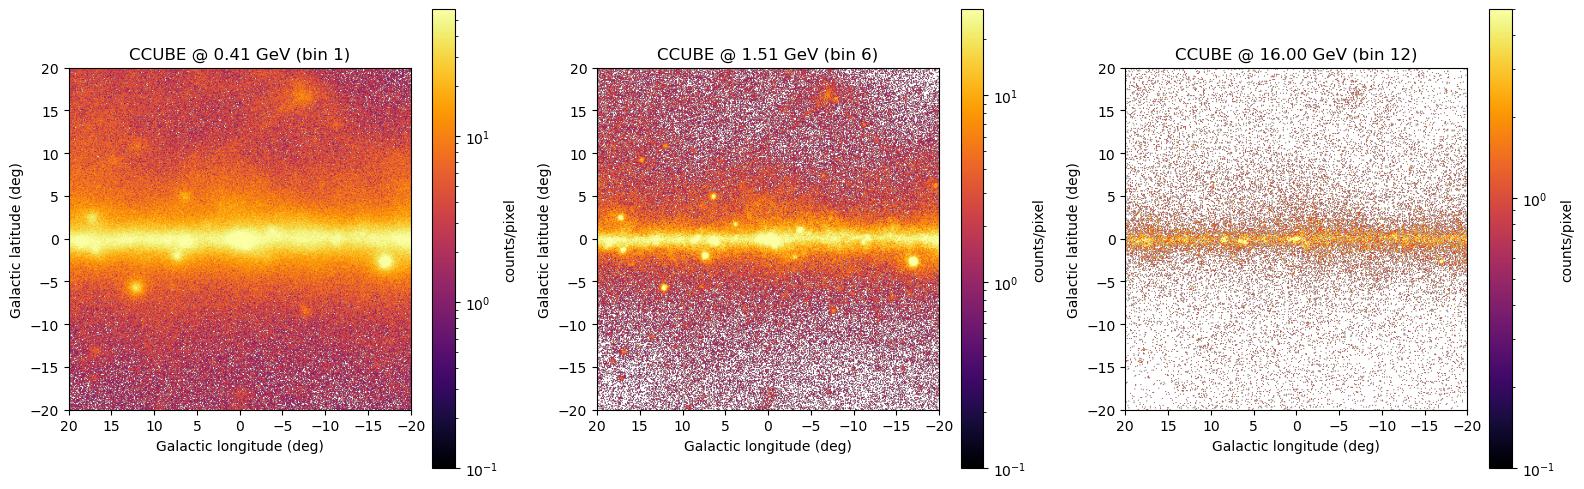

  총 카운트: 1.264e+07

9b. GCE / Bubbles 2D 템플릿 확인...


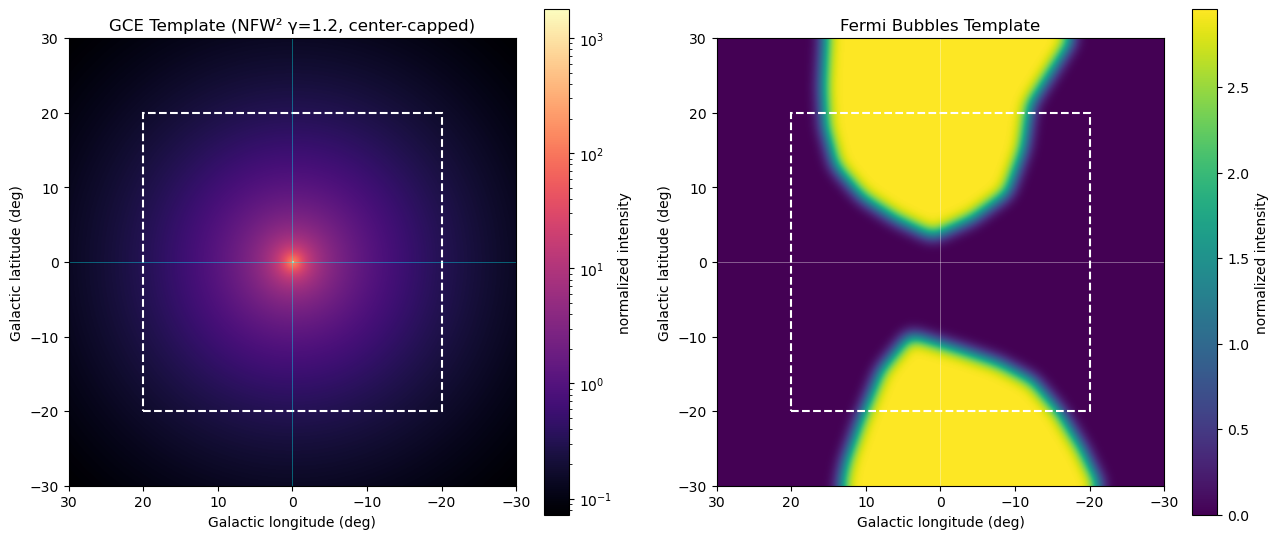


9c. 마스크 시각화...


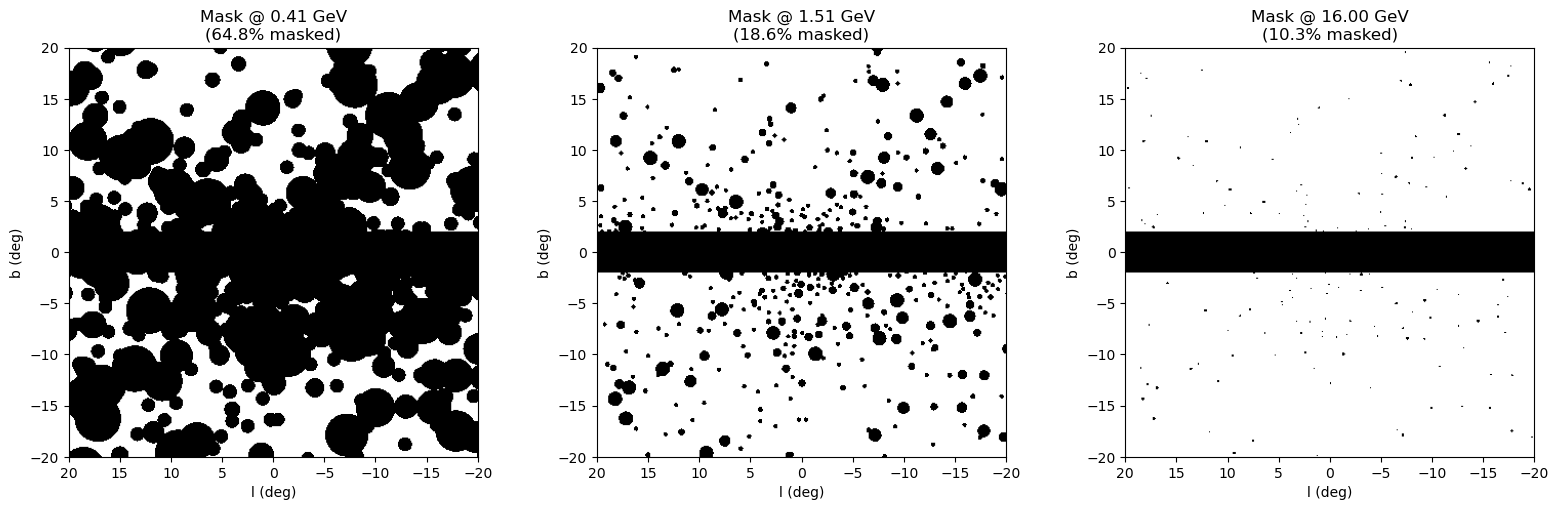


9d. 외부 제약 (bubble/iso) 시각화...


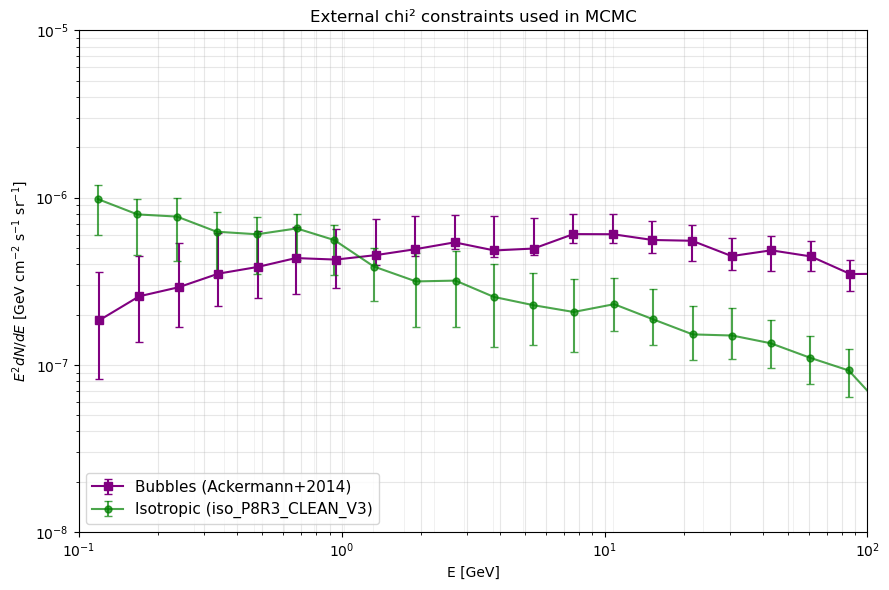

In [36]:
# %% ══════════════════════════════════════════════════════════
# SECTION 9: 진단 플롯 — 데이터/템플릿/마스크/성분 시각화
# ══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle

PLOT_DIR = os.path.join(WORK_DIR, 'diagnostic_plots_v6')
os.makedirs(PLOT_DIR, exist_ok=True)

# ── 9a. CCUBE 데이터 맵 ───────────────────────────────────
print("9a. CCUBE 데이터 맵 확인...")
with fits.open(ccube_file) as h:
    counts_data = h[0].data  # (14, 600, 600)

rep_bins = [1, 6, 12]
rep_labels = [f'{ENERGY_CENTERS_GEV[i]:.2f} GeV' for i in rep_bins]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, ie, label in zip(axes, rep_bins, rep_labels):
    img = counts_data[ie, OFFSET:OFFSET+NY_FIT, OFFSET:OFFSET+NX_FIT]
    vmax = np.percentile(img[img > 0], 99) if np.any(img > 0) else 1
    im = ax.imshow(img, origin='lower', cmap='inferno',
                   norm=LogNorm(vmin=max(img.min(), 0.1), vmax=vmax),
                   extent=[20, -20, -20, 20])
    ax.set_title(f'CCUBE @ {label} (bin {ie})')
    ax.set_xlabel('Galactic longitude (deg)')
    ax.set_ylabel('Galactic latitude (deg)')
    plt.colorbar(im, ax=ax, label='counts/pixel')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '9a_ccube_data.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f"  총 카운트: {counts_data.sum():.3e}")


# %% ── 9b. GCE / Bubbles 2D 템플릿 ─────────────────────────
print("\n9b. GCE / Bubbles 2D 템플릿 확인...")
gce_2d = fits.open(gce_fits)[0].data
bub_2d = fits.open(bub_fits)[0].data

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

im0 = axes[0].imshow(gce_2d, origin='lower', cmap='magma',
                     norm=LogNorm(vmin=gce_2d[gce_2d > 0].min(), vmax=gce_2d.max()),
                     extent=[30, -30, -30, 30])
axes[0].set_title('GCE Template (NFW² γ=1.2, center-capped)')
axes[0].set_xlabel('Galactic longitude (deg)')
axes[0].set_ylabel('Galactic latitude (deg)')
axes[0].axhline(0, color='cyan', lw=0.5, alpha=0.5)
axes[0].axvline(0, color='cyan', lw=0.5, alpha=0.5)
axes[0].add_patch(Rectangle((20, -20), -40, 40, fill=False,
                            edgecolor='white', lw=1.5, linestyle='--'))
plt.colorbar(im0, ax=axes[0], label='normalized intensity')

im1 = axes[1].imshow(bub_2d, origin='lower', cmap='viridis',
                     extent=[30, -30, -30, 30])
axes[1].set_title('Fermi Bubbles Template')
axes[1].set_xlabel('Galactic longitude (deg)')
axes[1].set_ylabel('Galactic latitude (deg)')
axes[1].axhline(0, color='white', lw=0.5, alpha=0.5)
axes[1].axvline(0, color='white', lw=0.5, alpha=0.5)
axes[1].add_patch(Rectangle((20, -20), -40, 40, fill=False,
                            edgecolor='white', lw=1.5, linestyle='--'))
plt.colorbar(im1, ax=axes[1], label='normalized intensity')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '9b_gce_bubbles_templates.png'), dpi=120, bbox_inches='tight')
plt.show()


# %% ── 9c. 마스크 시각화 ───────────────────────────────────
print("\n9c. 마스크 시각화...")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, ie, label in zip(axes, rep_bins, rep_labels):
    mask_crop = masks_3d[ie, OFFSET:OFFSET+NY_FIT, OFFSET:OFFSET+NX_FIT]
    masked_frac = 100.0 * (1 - mask_crop.mean())
    im = ax.imshow(mask_crop, origin='lower', cmap='gray',
                   vmin=0, vmax=1, extent=[20, -20, -20, 20])
    ax.set_title(f'Mask @ {label}\n({masked_frac:.1f}% masked)')
    ax.set_xlabel('l (deg)')
    ax.set_ylabel('b (deg)')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '9c_masks.png'), dpi=120, bbox_inches='tight')
plt.show()


# %% ── 9d. 외부 제약 스펙트럼 시각화 ──────────────────────
print("\n9d. 외부 제약 (bubble/iso) 시각화...")
fig, ax = plt.subplots(figsize=(9, 6))

# Bubble (이미 E²dN/dE)
ax.errorbar(bub_data[:, 0], bub_data[:, 1],
            yerr=[bub_data[:, 2], bub_data[:, 3]],
            fmt='s-', color='purple', capsize=3, markersize=6,
            label='Bubbles (Ackermann+2014)')

# Iso (dN/dE → E²dN/dE)
iso_E_plot  = iso_data[:, 0]
iso_sed     = iso_E_plot**2 * iso_data[:, 1]
iso_sed_lo  = iso_E_plot**2 * iso_data[:, 2]
iso_sed_hi  = iso_E_plot**2 * iso_data[:, 3]
ax.errorbar(iso_E_plot, iso_sed, yerr=[iso_sed_lo, iso_sed_hi],
            fmt='o-', color='green', capsize=3, markersize=5, alpha=0.7,
            label='Isotropic (iso_P8R3_CLEAN_V3)')

# 우리의 14 bin 경계 표시
for edge in ENERGY_EDGES_GEV:
    ax.axvline(edge, color='gray', alpha=0.15, lw=0.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.1, 100)
ax.set_ylim(1e-8, 1e-5)
ax.set_xlabel('E [GeV]')
ax.set_ylabel(r'$E^2 dN/dE$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
ax.set_title('External chi² constraints used in MCMC')
ax.legend(fontsize=11, loc='lower left')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '9d_external_constraints.png'), dpi=120, bbox_inches='tight')
plt.show()


로드된 모델: 80 / 80

--- -2 log L 랭킹 (상위 10개) ---
  ⭐ [ 1] Model   LXXX: -2logL = 3859472.60
     [ 2] Model LXXIII: -2logL = 3859478.18
     [ 3] Model  LXXIX: -2logL = 3859499.51
     [ 4] Model   XXXV: -2logL = 3859757.47
     [ 5] Model    III: -2logL = 3859892.44
     [ 6] Model LXXVII: -2logL = 3859908.48
     [ 7] Model  LXXII: -2logL = 3859928.38
     [ 8] Model LXXVIII: -2logL = 3859951.57
     [ 9] Model  XXXIV: -2logL = 3859984.90
     [10] Model XXXIII: -2logL = 3860045.68

🏆 Best-fit model: LXXX

10d. Best-fit 모델 전체 SED...


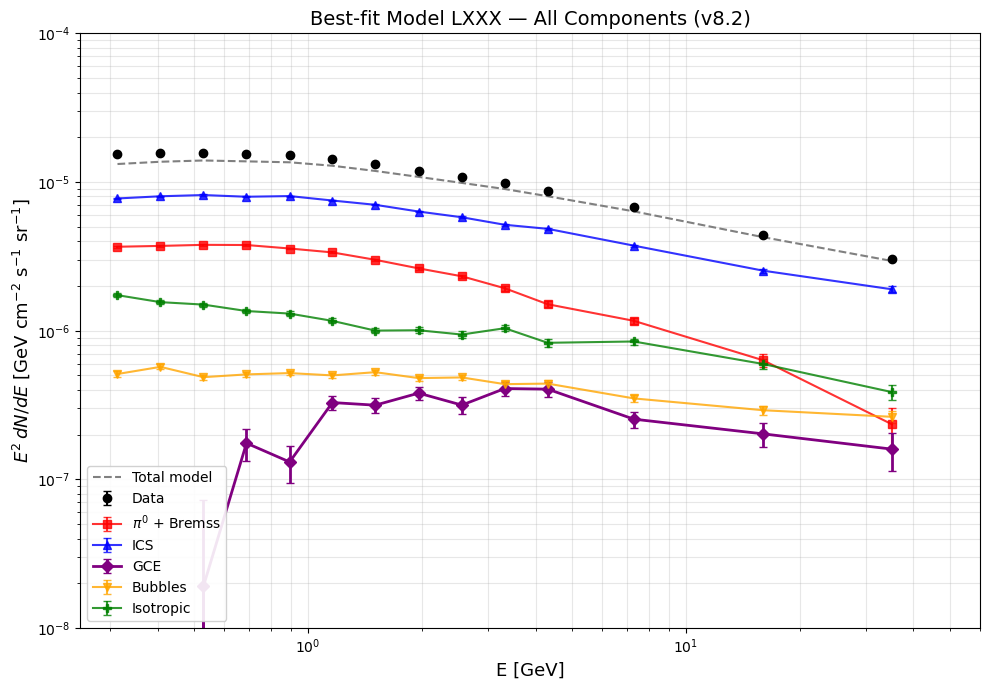

In [37]:
# %% ══════════════════════════════════════════════════════════
# SECTION 10: Best-fit 선정 + 전체 성분 SED (non-convol 사용)
# ══════════════════════════════════════════════════════════════
# ⭐ v8.2: compute_component_sed가 COMPMAP_DIR_NC (non-convol) 사용
# ══════════════════════════════════════════════════════════════

pkl_path = os.path.join(WORK_DIR, 'GCE_results_v8_2.pkl')
with open(pkl_path, 'rb') as f:
    all_results = pickle.load(f)

valid_results = [r for r in all_results if 'error' not in r]
print(f"로드된 모델: {len(valid_results)} / {len(all_results)}")

# -2 log L 랭킹
ll_list = [(r['model'], -2.0 * r['total_logL']) for r in valid_results]
ll_list.sort(key=lambda x: x[1])

print("\n--- -2 log L 랭킹 (상위 10개) ---")
for i, (name, neg2lnL) in enumerate(ll_list[:10]):
    marker = "⭐" if i == 0 else "  "
    print(f"  {marker} [{i+1:2d}] Model {name:>6}: -2logL = {neg2lnL:.2f}")

best_model = ll_list[0][0]
print(f"\n🏆 Best-fit model: {best_model}")


# ── Exposure × sr for SED 재구성 ──────────────────────────
exp_crop_fit = exp_cube_data[:, OFFSET:OFFSET+NY_FIT, OFFSET:OFFSET+NX_FIT]
sr_crop      = sr_per_pixel[OFFSET:OFFSET+NY_FIT, OFFSET:OFFSET+NX_FIT]
exp_cube_sr  = exp_crop_fit * sr_crop[np.newaxis, :, :]

disk_mask_crop = disk_mask_2d[OFFSET:OFFSET+NY_FIT, OFFSET:OFFSET+NX_FIT]


# ── SED 계산 함수 (⭐ non-convol 맵 사용) ─────────────────
def compute_component_sed(model_name, comp_file_name, c_arr, c_err_arr):
    fpath = os.path.join(COMPMAP_DIR_NC, f'{comp_file_name}_model{model_name}.fits')
    if not os.path.exists(fpath):
        return None, None
    with fits.open(fpath) as h:
        cmap = h[0].data[:, OFFSET:OFFSET+NY_FIT, OFFSET:OFFSET+NX_FIT]

    base = np.zeros(N_ENERGY_BINS)
    ds = disk_mask_crop.sum()
    for ie in range(N_ENERGY_BINS):
        base[ie] = np.sum(disk_mask_crop * cmap[ie] / np.maximum(exp_cube_sr[ie], 1e-30)) / ds

    E2 = ENERGY_CENTERS_GEV ** 2
    dE = ENERGY_WIDTHS_GEV
    return c_arr * base * E2 / dE, c_err_arr * base * E2 / dE


def compute_gas_sed(model_name, c_arr, c_err_arr):
    pion_fp = os.path.join(COMPMAP_DIR_NC, f'pion_model{model_name}.fits')
    brem_fp = os.path.join(COMPMAP_DIR_NC, f'bremss_model{model_name}.fits')
    if not (os.path.exists(pion_fp) and os.path.exists(brem_fp)):
        return None, None
    with fits.open(pion_fp) as h:
        pi0 = h[0].data[:, OFFSET:OFFSET+NY_FIT, OFFSET:OFFSET+NX_FIT]
    with fits.open(brem_fp) as h:
        brem = h[0].data[:, OFFSET:OFFSET+NY_FIT, OFFSET:OFFSET+NX_FIT]
    gas = pi0 + brem

    base = np.zeros(N_ENERGY_BINS)
    ds = disk_mask_crop.sum()
    for ie in range(N_ENERGY_BINS):
        base[ie] = np.sum(disk_mask_crop * gas[ie] / np.maximum(exp_cube_sr[ie], 1e-30)) / ds

    E2 = ENERGY_CENTERS_GEV ** 2
    dE = ENERGY_WIDTHS_GEV
    return c_arr * base * E2 / dE, c_err_arr * base * E2 / dE


def compute_gce_sed(model_name, c_gce_arr, c_gce_err_arr):
    return compute_component_sed(model_name, 'GCE', c_gce_arr, c_gce_err_arr)


# ── Best-fit 전체 SED ─────────────────────────────────────
print("\n10d. Best-fit 모델 전체 SED...")

best_result = next(r for r in valid_results if r['model'] == best_model)
norms = np.asarray(best_result['norms'])
errs  = np.asarray(best_result['errors'])

c_gas, c_ics, c_gce, c_bub, c_iso = norms[:, 0], norms[:, 1], norms[:, 2], norms[:, 3], norms[:, 4]
e_gas, e_ics, e_gce, e_bub, e_iso = errs[:, 0],  errs[:, 1],  errs[:, 2],  errs[:, 3],  errs[:, 4]

sed_gas, err_gas = compute_gas_sed(best_model, c_gas, e_gas)
sed_ics, err_ics = compute_component_sed(best_model, 'ics', c_ics, e_ics)
sed_gce, err_gce = compute_component_sed(best_model, 'GCE', c_gce, e_gce)
sed_bub, err_bub = compute_component_sed(best_model, 'Fermi_bubble', c_bub, e_bub)
sed_iso, err_iso = compute_component_sed(best_model, 'isotropic', c_iso, e_iso)

# Raw data SED
raw_sed = np.zeros(N_ENERGY_BINS)
raw_err = np.zeros(N_ENERGY_BINS)
ds = disk_mask_crop.sum()
for ie in range(N_ENERGY_BINS):
    d = counts_data[ie, OFFSET:OFFSET+NY_FIT, OFFSET:OFFSET+NX_FIT]
    raw_sed[ie] = np.sum(disk_mask_crop * d / np.maximum(exp_cube_sr[ie], 1e-30)) / ds
    raw_err[ie] = np.sqrt(np.sum(disk_mask_crop * d / np.maximum(exp_cube_sr[ie], 1e-30)**2)) / ds
raw_sed = raw_sed * ENERGY_CENTERS_GEV**2 / ENERGY_WIDTHS_GEV
raw_err = raw_err * ENERGY_CENTERS_GEV**2 / ENERGY_WIDTHS_GEV


fig, ax = plt.subplots(figsize=(10, 7))

ax.errorbar(ENERGY_CENTERS_GEV, raw_sed, yerr=raw_err,
            fmt='o', color='black', label='Data', markersize=6, capsize=3)

ax.errorbar(ENERGY_CENTERS_GEV, sed_gas, yerr=err_gas,
            fmt='s-', color='red', label=r'$\pi^0$ + Bremss', alpha=0.8, capsize=3)
ax.errorbar(ENERGY_CENTERS_GEV, sed_ics, yerr=err_ics,
            fmt='^-', color='blue', label='ICS', alpha=0.8, capsize=3)
ax.errorbar(ENERGY_CENTERS_GEV, sed_gce, yerr=err_gce,
            fmt='D-', color='purple', label='GCE', linewidth=2, capsize=3)
ax.errorbar(ENERGY_CENTERS_GEV, sed_bub, yerr=err_bub,
            fmt='v-', color='orange', label='Bubbles', alpha=0.8, capsize=3)
ax.errorbar(ENERGY_CENTERS_GEV, sed_iso, yerr=err_iso,
            fmt='P-', color='green', label='Isotropic', alpha=0.8, capsize=3)

sed_total = sed_gas + sed_ics + sed_gce + sed_bub + sed_iso
ax.plot(ENERGY_CENTERS_GEV, sed_total, '--', color='gray', label='Total model', linewidth=1.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.25, 60)
ax.set_ylim(1e-8, 1e-4)
ax.set_xlabel('E [GeV]', fontsize=13)
ax.set_ylabel(r'$E^2 \, dN/dE$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=13)
ax.set_title(f'Best-fit Model {best_model} — All Components (v8.2)', fontsize=14)
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, f'10_sed_best_model{best_model}.png'),
            dpi=120, bbox_inches='tight')
plt.show()


11a. Top 5 모델 GCE SED 비교...


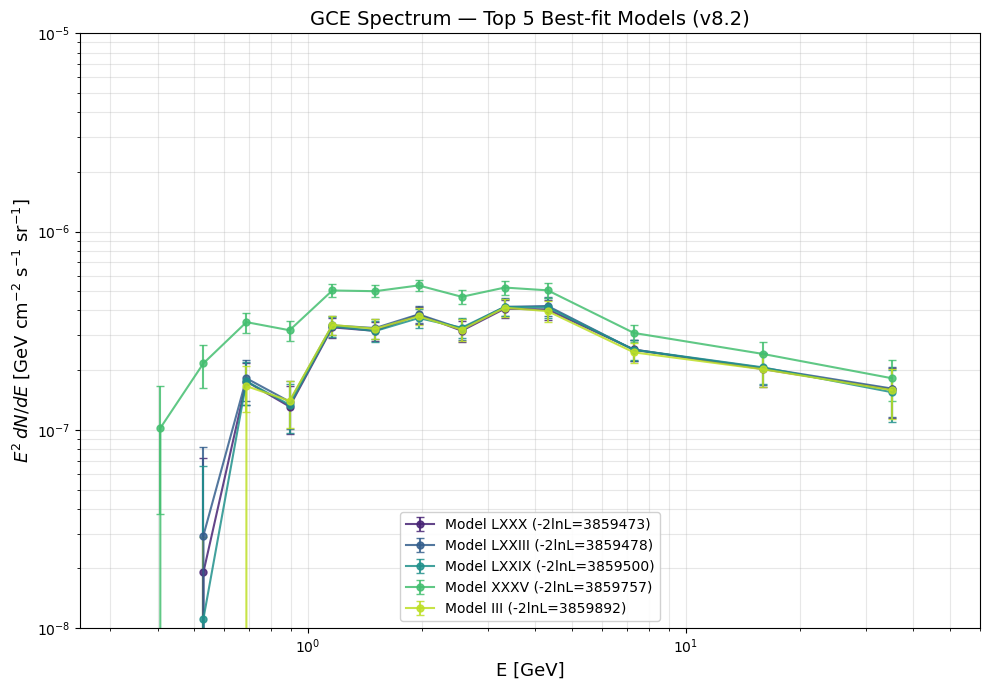


11b. 전체 모델 GCE SED envelope...
  수집된 모델: 80


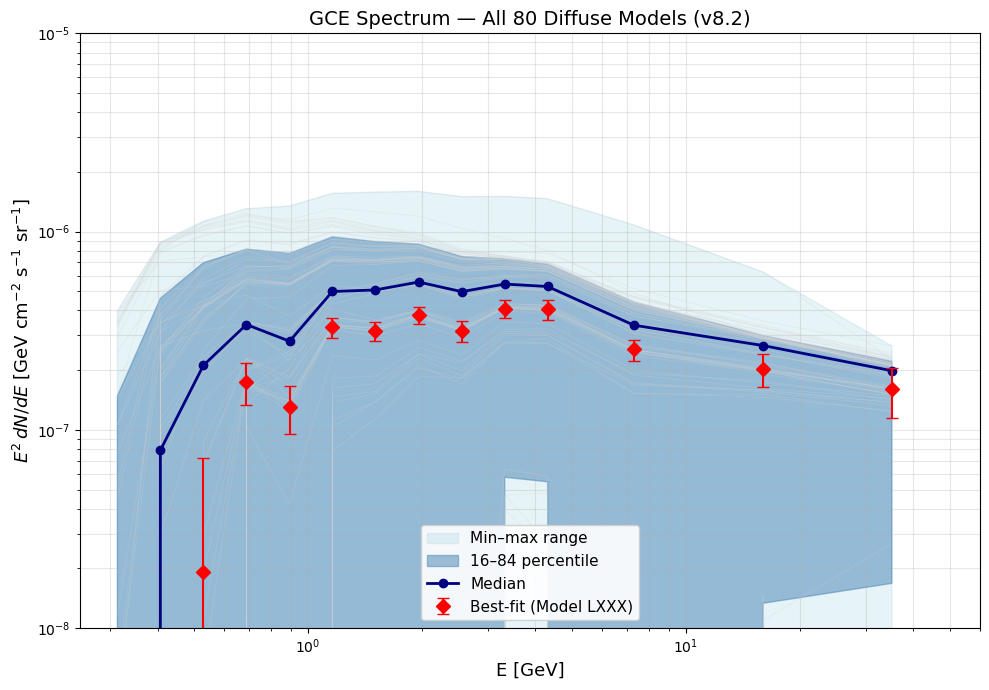


11c. 결과 CSV 저장...
✅ 결과 CSV 저장: /home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/GCE_fit_summary_v8_2_1.csv
✅ 진단 플롯 저장: /home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/diagnostic_plots_v6


In [38]:
# %% ══════════════════════════════════════════════════════════
# SECTION 11: 모델별 GCE SED 비교 + 결과 저장
# ══════════════════════════════════════════════════════════════

# ── 11a. Top 5 모델 GCE SED ───────────────────────────────
print("11a. Top 5 모델 GCE SED 비교...")

top_n = 5
top_models = [ll_list[i][0] for i in range(min(top_n, len(ll_list)))]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(top_models)))

fig, ax = plt.subplots(figsize=(10, 7))

for i, m_name in enumerate(top_models):
    r = next(rr for rr in valid_results if rr['model'] == m_name)
    nn = np.asarray(r['norms'])
    ee = np.asarray(r['errors'])
    sed, err = compute_gce_sed(m_name, nn[:, 2], ee[:, 2])
    if sed is None:
        continue
    n2l = -2 * r['total_logL']
    ax.errorbar(ENERGY_CENTERS_GEV, sed, yerr=err,
                fmt='o-', color=colors[i], alpha=0.85, capsize=3,
                label=f'Model {m_name} (-2lnL={n2l:.0f})',
                linewidth=1.5, markersize=5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.25, 60)
ax.set_ylim(1e-8, 1e-5)
ax.set_xlabel('E [GeV]', fontsize=13)
ax.set_ylabel(r'$E^2 \, dN/dE$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=13)
ax.set_title(f'GCE Spectrum — Top {top_n} Best-fit Models (v8.2)', fontsize=14)
ax.legend(loc='lower center', fontsize=10, framealpha=0.9)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '11a_gce_sed_top5.png'), dpi=120, bbox_inches='tight')
plt.show()


# ── 11b. 전체 모델 envelope ──────────────────────────────
print("\n11b. 전체 모델 GCE SED envelope...")

all_gce_seds = []
for r in valid_results:
    nn = np.asarray(r['norms'])
    ee = np.asarray(r['errors'])
    sed, _ = compute_gce_sed(r['model'], nn[:, 2], ee[:, 2])
    if sed is not None:
        all_gce_seds.append(sed)

all_gce_seds = np.array(all_gce_seds)
print(f"  수집된 모델: {len(all_gce_seds)}")

sed_median = np.median(all_gce_seds, axis=0)
sed_16     = np.percentile(all_gce_seds, 16, axis=0)
sed_84     = np.percentile(all_gce_seds, 84, axis=0)
sed_min    = np.min(all_gce_seds, axis=0)
sed_max    = np.max(all_gce_seds, axis=0)

fig, ax = plt.subplots(figsize=(10, 7))
for sed in all_gce_seds:
    ax.plot(ENERGY_CENTERS_GEV, sed, color='lightgray', alpha=0.25, linewidth=0.6)

ax.fill_between(ENERGY_CENTERS_GEV, sed_min, sed_max,
                color='lightblue', alpha=0.3, label='Min–max range')
ax.fill_between(ENERGY_CENTERS_GEV, sed_16, sed_84,
                color='steelblue', alpha=0.5, label='16–84 percentile')
ax.plot(ENERGY_CENTERS_GEV, sed_median, 'o-', color='navy',
        label='Median', linewidth=2, markersize=6)

best_r = next(rr for rr in valid_results if rr['model'] == best_model)
best_norms = np.asarray(best_r['norms'])
best_errs  = np.asarray(best_r['errors'])
best_sed, best_sed_err = compute_gce_sed(best_model, best_norms[:, 2], best_errs[:, 2])
ax.errorbar(ENERGY_CENTERS_GEV, best_sed, yerr=best_sed_err,
            fmt='D', color='red', markersize=7, capsize=4,
            label=f'Best-fit (Model {best_model})', zorder=10)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.25, 60)
ax.set_ylim(1e-8, 1e-5)
ax.set_xlabel('E [GeV]', fontsize=13)
ax.set_ylabel(r'$E^2 \, dN/dE$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=13)
ax.set_title(f'GCE Spectrum — All {len(all_gce_seds)} Diffuse Models (v8.2)', fontsize=14)
ax.legend(loc='lower center', fontsize=11, framealpha=0.9)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '11b_gce_sed_all_models.png'), dpi=120, bbox_inches='tight')
plt.show()


# ── 11c. CSV 저장 ─────────────────────────────────────────
print("\n11c. 결과 CSV 저장...")
import csv

n2lnL_vals = np.array([-2 * r['total_logL'] for r in valid_results])
delta_n2lnL = n2lnL_vals - n2lnL_vals.min()
sorted_idx = np.argsort(n2lnL_vals)

summary_csv = os.path.join(WORK_DIR, 'GCE_fit_summary_v8_2_1.csv')
with open(summary_csv, 'w', newline='') as f:
    writer = csv.writer(f)
    header = ['Model', '-2logL', 'delta_-2logL', 'rank']
    for ie in range(N_ENERGY_BINS):
        header += [f'E{ie}_GeV', f'GCE_E2dNdE_{ie}', f'GCE_err_{ie}']
    writer.writerow(header)

    for rank, idx in enumerate(sorted_idx):
        r = valid_results[idx]
        nn = np.asarray(r['norms'])
        ee = np.asarray(r['errors'])
        sed, err = compute_gce_sed(r['model'], nn[:, 2], ee[:, 2])

        row = [r['model'], f"{n2lnL_vals[idx]:.2f}",
               f"{delta_n2lnL[idx]:.2f}", rank + 1]
        if sed is not None:
            for ie in range(N_ENERGY_BINS):
                row += [f"{ENERGY_CENTERS_GEV[ie]:.4f}",
                        f"{sed[ie]:.4e}", f"{err[ie]:.4e}"]
        writer.writerow(row)

print(f"✅ 결과 CSV 저장: {summary_csv}")
print(f"✅ 진단 플롯 저장: {PLOT_DIR}")



--- Pipeline Model X vs Zenodo Model X ---
   E [GeV]       Zenodo     Pipeline  Ratio (P/Z)
--------------------------------------------------
     0.313    6.060e-07    1.066e-07        0.176
     0.407    6.458e-07    3.122e-07        0.483
     0.529    6.790e-07    4.217e-07        0.621
     0.688    7.372e-07    5.881e-07        0.798
     0.894    7.203e-07    5.458e-07        0.758
     1.160    9.241e-07    7.135e-07        0.772
     1.507    9.190e-07    7.024e-07        0.764
     1.963    9.092e-07    7.145e-07        0.786
     2.553    8.039e-07    6.268e-07        0.780
     3.317    8.311e-07    6.590e-07        0.793
     4.308    7.607e-07    6.257e-07        0.822
     7.282    4.745e-07    4.040e-07        0.851
    15.999    3.021e-07    2.905e-07        0.962
    35.072    1.743e-07    2.129e-07        1.221

평균 비율: 0.756
중앙값 비율: 0.783
1-10 GeV 구간 평균 비율: 0.782


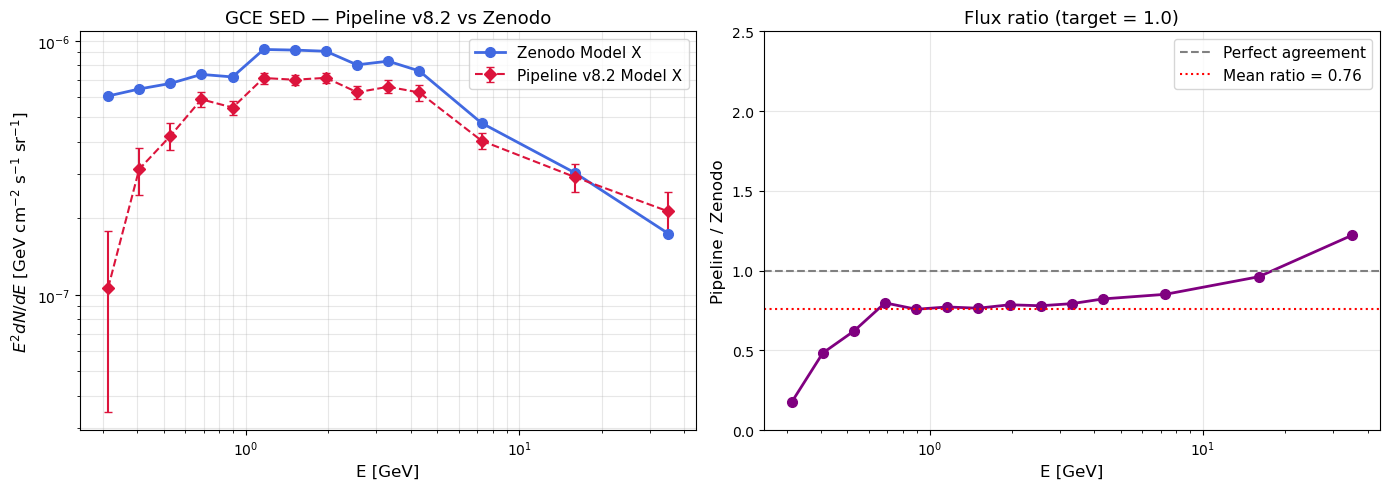


🎯 v8.2 성공 기준: ratio가 0.95~1.05 범위에 있어야 함
   (v5/v6/v7에서는 ~0.755로 보고됨)
   ⭐ v8.2 진짜 fix: MapCube ENERGY GRID를 native 38 nodes로 보존
      → c_gas, c_ics가 0.001에서 ~1.0으로 정상화
      → fit이 GCE만 강제로 키우지 않게 됨


In [39]:
# %% ══════════════════════════════════════════════════════════
# SECTION 12: Pipeline vs Zenodo 직접 비교 (진단)
# ══════════════════════════════════════════════════════════════
# 이 셀은 Model X의 결과를 Zenodo에 저장된 저자의 Model X flux와
# 직접 비교하여 파이프라인의 systematic offset을 확인합니다.
# ══════════════════════════════════════════════════════════════

zenodo_file = '/home/haebarg/GCE-Chi-square-fitting/GCE_TEMPLATES_FILES_v3/Figures_12_and_14_GCE_Spectra/GCE_ModelX_flux_Inner40x40_masked_disk.dat'

if os.path.exists(zenodo_file):
    g = np.loadtxt(zenodo_file)
    zen_e  = g[:N_ENERGY_BINS, 0]
    zen_f  = g[:N_ENERGY_BINS, 1]
    zen_lo = g[:N_ENERGY_BINS, 2] if g.shape[1] > 2 else None
    zen_hi = g[:N_ENERGY_BINS, 3] if g.shape[1] > 3 else None

    # Model X 결과
    model_x_result = next((r for r in valid_results if r['model'] == 'X'), None)
    if model_x_result is None:
        print("⚠️ Model X 결과 없음 — best-fit 사용")
        model_x_result = next(r for r in valid_results if r['model'] == best_model)

    nn = np.asarray(model_x_result['norms'])
    ee = np.asarray(model_x_result['errors'])
    pl_sed, pl_err = compute_gce_sed(model_x_result['model'], nn[:, 2], ee[:, 2])

    # 비율
    ratio = pl_sed / zen_f
    print(f"\n--- Pipeline Model {model_x_result['model']} vs Zenodo Model X ---")
    print(f"{'E [GeV]':>10} {'Zenodo':>12} {'Pipeline':>12} {'Ratio (P/Z)':>12}")
    print("-" * 50)
    for ie in range(N_ENERGY_BINS):
        print(f"{ENERGY_CENTERS_GEV[ie]:10.3f} {zen_f[ie]:12.3e} "
              f"{pl_sed[ie]:12.3e} {ratio[ie]:12.3f}")

    print(f"\n평균 비율: {np.mean(ratio):.3f}")
    print(f"중앙값 비율: {np.median(ratio):.3f}")
    print(f"1-10 GeV 구간 평균 비율: {np.mean(ratio[4:11]):.3f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.errorbar(zen_e, zen_f, fmt='o-', color='royalblue',
                 label='Zenodo Model X', markersize=7, linewidth=2)
    ax1.errorbar(ENERGY_CENTERS_GEV, pl_sed, yerr=pl_err,
                 fmt='D--', color='crimson',
                 label=f'Pipeline v8.2 Model {model_x_result["model"]}',
                 markersize=6, capsize=3)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('E [GeV]', fontsize=12)
    ax1.set_ylabel(r'$E^2 dN/dE$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=12)
    ax1.set_title('GCE SED — Pipeline v8.2 vs Zenodo', fontsize=13)
    ax1.legend(fontsize=11)
    ax1.grid(True, which='both', alpha=0.3)

    ax2.plot(ENERGY_CENTERS_GEV, ratio, 'o-', color='purple', markersize=7, linewidth=2)
    ax2.axhline(1.0, color='gray', linestyle='--', label='Perfect agreement')
    ax2.axhline(np.mean(ratio), color='red', linestyle=':',
                label=f'Mean ratio = {np.mean(ratio):.2f}')
    ax2.set_xscale('log')
    ax2.set_xlabel('E [GeV]', fontsize=12)
    ax2.set_ylabel('Pipeline / Zenodo', fontsize=12)
    ax2.set_title('Flux ratio (target = 1.0)', fontsize=13)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 2.5)

    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, '12_pipeline_vs_zenodo.png'), dpi=120, bbox_inches='tight')
    plt.show()

    print("\n🎯 v8.2 성공 기준: ratio가 0.95~1.05 범위에 있어야 함")
    print("   (v5/v6/v7에서는 ~0.755로 보고됨)")
    print("   ⭐ v8.2 진짜 fix: MapCube ENERGY GRID를 native 38 nodes로 보존")
    print("      → c_gas, c_ics가 0.001에서 ~1.0으로 정상화")
    print("      → fit이 GCE만 강제로 키우지 않게 됨")
else:
    print(f"⚠️ Zenodo 파일 없음: {zenodo_file}")
    print("   Pipeline vs Zenodo 비교 건너뜀")


13. DM 파라미터 χ² Contour 분석 (v8.2)

Zenodo 참조 데이터 로드...
  Zenodo flux: 14 bins, 0.313-35.0 GeV

80개 모델 GCE SED 행렬 구축...
  유효 모델: 80, 에너지 빈: 14
  Fiducial model: X

Correlation PCA 기반 systematic 공분산 구축...

χ² 그리드 스캔...

  ─── Pipeline v8.2 (Fiducial: X) ───
    Best-fit mass : 31.7 GeV
    Best-fit σv   : 2.89e-27 cm³/s
    χ²_min/dof    : 33.33/12 = 2.777

  ─── Zenodo (Cholis 2022) ───
    Best-fit mass : 46.5 GeV
    Best-fit σv   : 1.19e-26 cm³/s
    χ²_min/dof    : 23.66/12 = 1.971


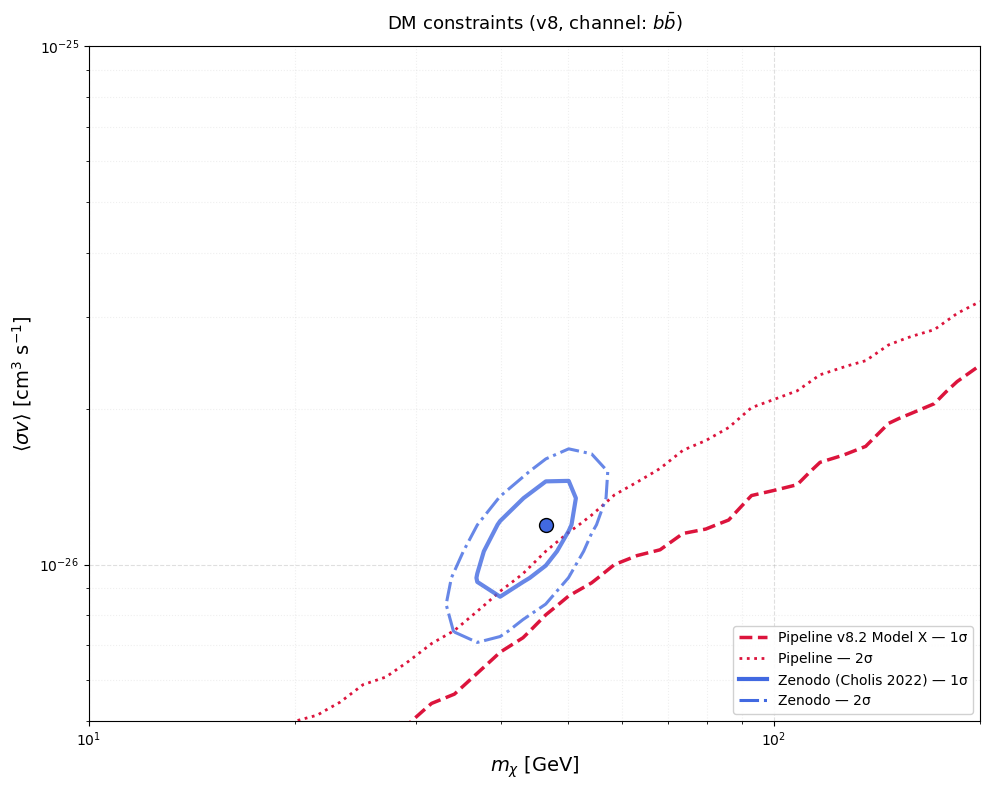


✅ v8.2 분석 완료
   주요 파일:
     - /home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/GCE_results_v8_2.pkl
     - /home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/GCE_fit_summary_v8_2_1.csv
     - /home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/diagnostic_plots_v6/


In [40]:
# %% ══════════════════════════════════════════════════════════
# SECTION 13: DM parameter constraints — χ² contour
# ══════════════════════════════════════════════════════════════
# (v5 Section 12와 동일한 구조, 결과 파일 경로만 v7로 변경)
# ══════════════════════════════════════════════════════════════
from matplotlib.lines import Line2D

BASE_DIR        = '/home/haebarg/GCE-Chi-square-fitting/'
ZENODO_DIR      = os.path.join(BASE_DIR, 'GCE_TEMPLATES_FILES_v3/Figures_12_and_14_GCE_Spectra/')
COV_INFO_DIR    = os.path.join(BASE_DIR, 'GCE_TEMPLATES_FILES_v3/Covariance_Matrix_Information/')
ZENODO_FLUX_FILE = os.path.join(ZENODO_DIR, 'GCE_ModelX_flux_Inner40x40_masked_disk.dat')
STAT_ERR_FILE    = os.path.join(COV_INFO_DIR, 'GCE_Statistical_errors.dat')
FULL_COV_FILE    = os.path.join(COV_INFO_DIR, 'cov_mat_21Dec02.npy')

PPPC4_PATHS = [
    './Prompt_spectra/',
    '/home/haebarg/ipynb/',
    '/home/haebarg/Prompt_spectra/',
    os.path.join(WORK_DIR, 'Prompt_spectra/'),
    os.path.join(BASE_DIR, 'Prompt_spectra/'),
]

J_FACTOR     = 3.5251837158376415e+21  # GeV² cm⁻⁵
CHANNEL_COL  = 13
CHANNEL_NAME = 'bb'
FIDUCIAL_MODEL = 'X'
bin_len = N_ENERGY_BINS


def load_pppc4_spectrum(mass_gev, channel_col, type_particle='gammas', EW='Yes'):
    filename = f"AtProduction_{type_particle}.dat" if EW == 'Yes' else f"AtProduction_NoEW_{type_particle}.dat"

    full_path = None
    for p in PPPC4_PATHS:
        candidate = os.path.join(p, filename)
        if os.path.exists(candidate):
            full_path = candidate
            break
    if full_path is None:
        raise FileNotFoundError(f"PPPC4 파일 없음: {filename}, paths={PPPC4_PATHS}")

    data = np.loadtxt(full_path, skiprows=1)
    m_grid    = np.unique(data[:, 0])
    logx_grid = np.unique(data[:, 1])
    z_values  = data[:, channel_col].reshape(len(m_grid), len(logx_grid))

    interp_func = RegularGridInterpolator(
        (m_grid, logx_grid), z_values,
        bounds_error=False, fill_value=None
    )

    points = np.array([[mass_gev, lx] for lx in logx_grid])
    dNdlogx = interp_func(points)
    energy_axis = mass_gev * (10 ** logx_grid)

    with np.errstate(divide='ignore', invalid='ignore'):
        dNdE = dNdlogx / (energy_axis * np.log(10))

    return energy_axis, np.nan_to_num(dNdE, nan=0.0, posinf=0.0, neginf=0.0)


# ── Zenodo 참조 데이터 로드 ────────────────────────────────
print("=" * 60)
print("13. DM 파라미터 χ² Contour 분석 (v8.2)")
print("=" * 60)

has_zenodo = all(os.path.exists(f) for f in [ZENODO_FLUX_FILE, STAT_ERR_FILE, FULL_COV_FILE])

if has_zenodo:
    print("\nZenodo 참조 데이터 로드...")
    g = np.loadtxt(ZENODO_FLUX_FILE)
    zen_emeans = g[:bin_len, 0]
    zen_flux   = g[:bin_len, 1]

    stat_unc_author = np.loadtxt(STAT_ERR_FILE)[:bin_len, 1]

    full_cov_raw = np.load(FULL_COV_FILE)
    U_auth, S_auth, Vh_auth = np.linalg.svd(full_cov_raw)
    cov_sys_author = sum(
        S_auth[i] * np.outer(U_auth.T[i], Vh_auth[i])
        for i in range(3)
    )
    cov_total_author = np.diag(stat_unc_author ** 2) + cov_sys_author
    inv_cov_author = np.linalg.inv(cov_total_author)

    print(f"  Zenodo flux: {bin_len} bins, {zen_emeans[0]:.3f}-{zen_emeans[-1]:.1f} GeV")
else:
    print("\n⚠️ Zenodo 참조 파일 없음 — 파이프라인 결과만 플롯")
    zen_emeans, zen_flux = None, None
    inv_cov_author = None


# ── 파이프라인 flux 행렬 구축 ──────────────────────────────
print("\n80개 모델 GCE SED 행렬 구축...")

flux_matrix = []
fit_stat_err_fid = None

for r in valid_results:
    norms = np.asarray(r['norms'])
    errs  = np.asarray(r['errors'])
    sed, err_sed = compute_gce_sed(r['model'], norms[:, 2], errs[:, 2])
    if sed is not None and not np.any(np.isnan(sed)):
        flux_matrix.append(sed)
        if r['model'] == FIDUCIAL_MODEL:
            fit_stat_err_fid = err_sed

flux_matrix = np.array(flux_matrix)
print(f"  유효 모델: {flux_matrix.shape[0]}, 에너지 빈: {flux_matrix.shape[1]}")

fid_result = next((r for r in valid_results if r['model'] == FIDUCIAL_MODEL), None)
if fid_result is None:
    print(f"  ⚠️ Fiducial '{FIDUCIAL_MODEL}' 없음 → 첫 모델 사용")
    fid_result = valid_results[0]
    FIDUCIAL_MODEL = fid_result['model']

fid_norms = np.asarray(fid_result['norms'])
fid_errs  = np.asarray(fid_result['errors'])
fid_flux, fit_stat_err_fid = compute_gce_sed(FIDUCIAL_MODEL, fid_norms[:, 2], fid_errs[:, 2])

print(f"  Fiducial model: {FIDUCIAL_MODEL}")


# ── Correlation PCA + 잔차 대각 복원 ──────────────────────
print("\nCorrelation PCA 기반 systematic 공분산 구축...")

cov_sys_raw = np.cov(flux_matrix.T, bias=False)
stds = np.sqrt(np.diag(cov_sys_raw))
stds_safe = np.where(stds > 0, stds, 1e-30)
corr_matrix = cov_sys_raw / np.outer(stds_safe, stds_safe)

U, S, Vh = np.linalg.svd(corr_matrix)
corr_trunc = sum(S[i] * np.outer(U[:, i], Vh[i, :]) for i in range(3))

residuals = 1.0 - np.diag(corr_trunc)
residuals = np.maximum(residuals, 0)
corr_trunc += np.diag(residuals)

cov_sys_pipeline = corr_trunc * np.outer(stds, stds)

if fit_stat_err_fid is None or np.any(np.isnan(fit_stat_err_fid)):
    if has_zenodo:
        fit_stat_err_fid = stat_unc_author.copy()
    else:
        fit_stat_err_fid = np.abs(fid_flux) * 0.1

invalid = np.isnan(fit_stat_err_fid) | (fit_stat_err_fid <= 0)
if has_zenodo and np.any(invalid):
    fit_stat_err_fid[invalid] = stat_unc_author[invalid]

cov_stat_pipeline  = np.diag(fit_stat_err_fid ** 2)
cov_total_pipeline = cov_stat_pipeline + cov_sys_pipeline
inv_cov_pipeline   = np.linalg.inv(cov_total_pipeline)


# ── χ² 그리드 스캔 ─────────────────────────────────────────
print("\nχ² 그리드 스캔...")

def chi2_dm(dm_mass, sigma_v, data_flux, inv_cov, emeans_target):
    warnings.simplefilter("ignore", category=RuntimeWarning)

    energy_axis, dNdE_vals = load_pppc4_spectrum(dm_mass, CHANNEL_COL, 'gammas', 'Yes')
    dNdE_interp = interp1d(
        energy_axis, dNdE_vals,
        fill_value=0, bounds_error=False, kind='linear'
    )(emeans_target)

    model_flux = (emeans_target ** 2) * dNdE_interp * \
                 (sigma_v / (dm_mass ** 2)) * J_FACTOR / SR_ROI

    delta = model_flux - data_flux
    return delta @ inv_cov @ delta

N_GRID = 40
mass_range   = np.logspace(np.log10(10), np.log10(200), N_GRID)
sigmav_range = np.logspace(-27, -25, N_GRID)
DM_MASS, SIGMAV = np.meshgrid(mass_range, sigmav_range)

chi2_pipeline = np.vectorize(
    lambda m, sv: chi2_dm(m, sv, fid_flux, inv_cov_pipeline, ENERGY_CENTERS_GEV)
)(DM_MASS, SIGMAV)

if has_zenodo:
    chi2_zenodo = np.vectorize(
        lambda m, sv: chi2_dm(m, sv, zen_flux, inv_cov_author, zen_emeans)
    )(DM_MASS, SIGMAV)
else:
    chi2_zenodo = None

idx_min_pl = np.unravel_index(np.argmin(chi2_pipeline), chi2_pipeline.shape)
min_chi2_pl = chi2_pipeline[idx_min_pl]
bf_mass_pl  = DM_MASS[idx_min_pl]
bf_sv_pl    = SIGMAV[idx_min_pl]

if has_zenodo:
    idx_min_zen = np.unravel_index(np.argmin(chi2_zenodo), chi2_zenodo.shape)
    min_chi2_zen = chi2_zenodo[idx_min_zen]
    bf_mass_zen  = DM_MASS[idx_min_zen]
    bf_sv_zen    = SIGMAV[idx_min_zen]

dof = bin_len - 2

print(f"\n  ─── Pipeline v8.2 (Fiducial: {FIDUCIAL_MODEL}) ───")
print(f"    Best-fit mass : {bf_mass_pl:.1f} GeV")
print(f"    Best-fit σv   : {bf_sv_pl:.2e} cm³/s")
print(f"    χ²_min/dof    : {min_chi2_pl:.2f}/{dof} = {min_chi2_pl/dof:.3f}")

if has_zenodo:
    print(f"\n  ─── Zenodo (Cholis 2022) ───")
    print(f"    Best-fit mass : {bf_mass_zen:.1f} GeV")
    print(f"    Best-fit σv   : {bf_sv_zen:.2e} cm³/s")
    print(f"    χ²_min/dof    : {min_chi2_zen:.2f}/{dof} = {min_chi2_zen/dof:.3f}")


# ── Contour plot ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

levels_1s2s_pl = [min_chi2_pl + 2.30, min_chi2_pl + 6.18]
ax.contour(DM_MASS, SIGMAV, chi2_pipeline, levels=levels_1s2s_pl,
           colors='crimson', linestyles=['--', ':'], linewidths=[2.5, 2])
ax.plot(bf_mass_pl, bf_sv_pl, marker='*', color='crimson',
        markersize=16, markeredgecolor='black', zorder=10)

if has_zenodo:
    levels_1s2s_zen = [min_chi2_zen + 2.30, min_chi2_zen + 6.18]
    ax.contour(DM_MASS, SIGMAV, chi2_zenodo, levels=levels_1s2s_zen,
               colors='royalblue', linestyles=['-', '-.'], linewidths=[3, 2.2],
               alpha=0.8)
    ax.plot(bf_mass_zen, bf_sv_zen, marker='o', color='royalblue',
            markersize=10, markeredgecolor='black', zorder=10)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(10, 200)
ax.set_ylim(5e-27, 1e-25)
ax.set_xlabel(r'$m_\chi$ [GeV]', fontsize=14)
ax.set_ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=14)
ax.set_title(f'DM constraints (v8, channel: $b\\bar{{b}}$)', fontsize=13, pad=12)
ax.grid(True, which='major', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)

legend_lines, legend_labels = [], []
legend_lines.append(Line2D([0], [0], color='crimson', lw=2.5, linestyle='--'))
legend_labels.append(f'Pipeline v8.2 Model {FIDUCIAL_MODEL} — 1σ')
legend_lines.append(Line2D([0], [0], color='crimson', lw=2, linestyle=':'))
legend_labels.append('Pipeline — 2σ')
if has_zenodo:
    legend_lines.append(Line2D([0], [0], color='royalblue', lw=3, linestyle='-'))
    legend_labels.append('Zenodo (Cholis 2022) — 1σ')
    legend_lines.append(Line2D([0], [0], color='royalblue', lw=2.2, linestyle='-.'))
    legend_labels.append('Zenodo — 2σ')
ax.legend(legend_lines, legend_labels, loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '13_dm_chi2_contour.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ── 저장 ──────────────────────────────────────────────────
np.save(os.path.join(WORK_DIR, 'cov_sys_pipeline_v8_2_1.npy'), cov_sys_pipeline)
np.save(os.path.join(WORK_DIR, 'cov_total_pipeline_v8_2_1.npy'), cov_total_pipeline)
np.save(os.path.join(WORK_DIR, 'flux_matrix_80models_v8_2_1.npy'), flux_matrix)

print(f"\n✅ v8.2 분석 완료")
print(f"   주요 파일:")
print(f"     - {pkl_path}")
print(f"     - {os.path.join(WORK_DIR, 'GCE_fit_summary_v8_2_1.csv')}")
print(f"     - {PLOT_DIR}/")



14. 80-Model Envelope vs Zenodo
  유효 GCE SED: 80/80 모델

  SED matrix shape: (80, 14)
  bin별 model spread (max/min):
    ie= 0, E=  0.31 GeV: median=-1.765e-07, spread=infx
    ie= 1, E=  0.41 GeV: median=7.888e-08, spread=infx
    ie= 2, E=  0.53 GeV: median=2.115e-07, spread=infx
    ie= 3, E=  0.69 GeV: median=3.397e-07, spread=infx
    ie= 4, E=  0.89 GeV: median=2.800e-07, spread=infx
    ie= 5, E=  1.16 GeV: median=4.987e-07, spread=infx
    ie= 6, E=  1.51 GeV: median=5.077e-07, spread=infx
    ie= 7, E=  1.96 GeV: median=5.566e-07, spread=infx
    ie= 8, E=  2.55 GeV: median=4.979e-07, spread=infx
    ie= 9, E=  3.32 GeV: median=5.436e-07, spread=infx
    ie=10, E=  4.31 GeV: median=5.286e-07, spread=infx
    ie=11, E=  7.28 GeV: median=3.373e-07, spread=infx
    ie=12, E= 16.00 GeV: median=2.662e-07, spread=infx
    ie=13, E= 35.07 GeV: median=1.987e-07, spread=infx

  --- 80-model envelope vs Zenodo Model X ---
   ie   E[GeV]      Zenodo         min      median         max  i

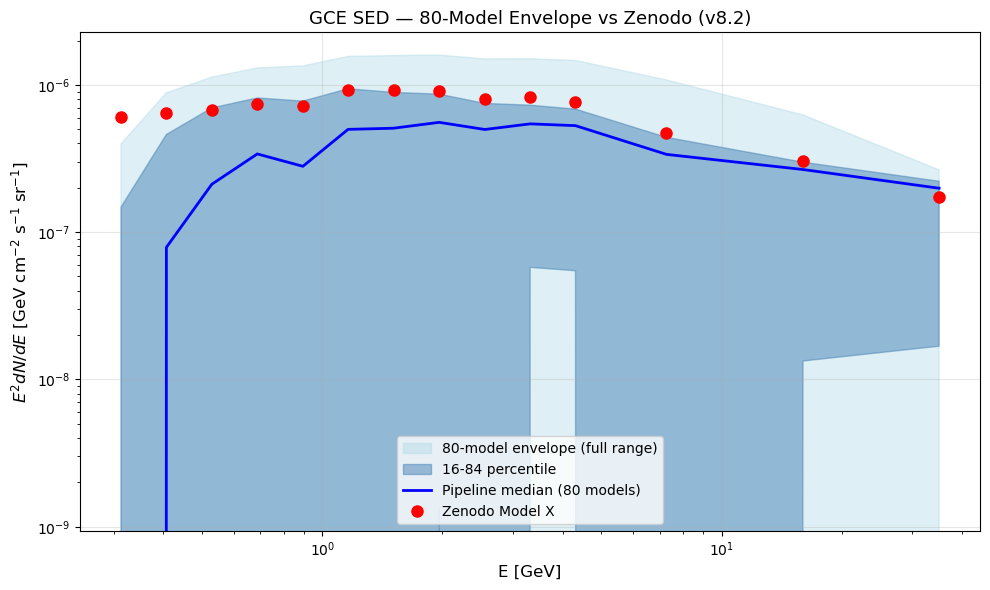

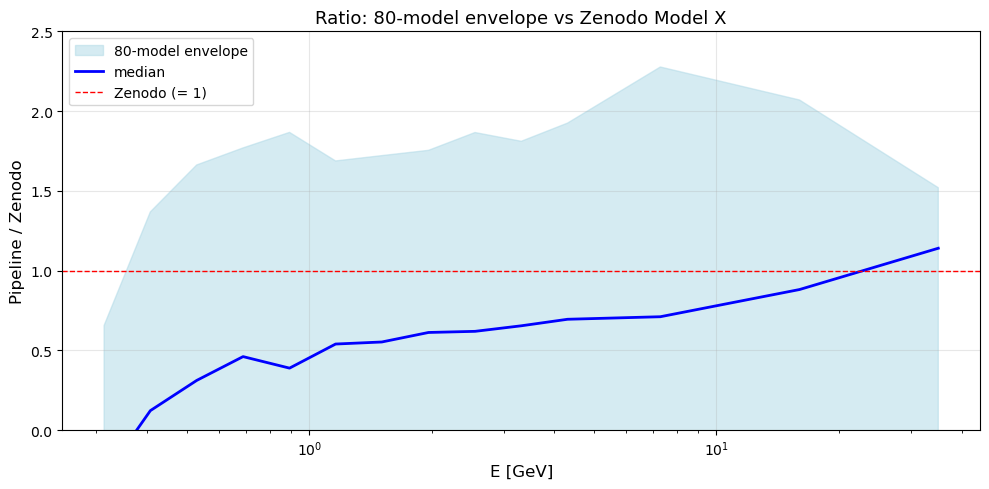


해석:
  - Zenodo가 envelope 내에 모두 들어간다면 (✅×14):
    → 우리 single Model X 결과(0.75 ratio)는 80-model spread의 정상 변동
    → 분석은 본질적으로 맞고, Zenodo Model X 자체가 outlier
  - 일부만 envelope 내라면 (예: ✅×7):
    → systematic 차이가 envelope 너비보다 큼
    → 추가 fix 필요 (EDISP 외)
  - 거의 envelope 밖이면:
    → fundamental 불일치 → 추가 디버깅


In [41]:
# %% ══════════════════════════════════════════════════════════
# SECTION 14: 80-model envelope vs Zenodo (v8.2 추가)
# ══════════════════════════════════════════════════════════════
# Cholis 2022 Fig 12, 14의 'Pipeline' 밴드는 80개 GDE 모델의 envelope.
# 우리도 같은 envelope을 만들어서 single Model X 비교의 한계를 봅니다.
#
# Cholis 본인의 코멘트 (Sec V):
#   "different choices for the underlying GDE model lead to ~10-50%
#    spread in inferred GCE flux"
#
# 그러므로 single-model ratio 0.755가 80-model envelope 안에 들어가는지가
# 진짜 검증의 핵심.
# ══════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("14. 80-Model Envelope vs Zenodo")
print("=" * 60)

# 모든 valid 모델의 GCE SED 계산
all_gce_seds = {}
for r in valid_results:
    mname = r['model']
    nn = np.asarray(r['norms'])
    ee = np.asarray(r['errors'])
    sed, err = compute_gce_sed(mname, nn[:, 2], ee[:, 2])
    if sed is not None:
        all_gce_seds[mname] = (sed, err)

print(f"  유효 GCE SED: {len(all_gce_seds)}/{len(valid_results)} 모델")

if len(all_gce_seds) < 5:
    print("  ⚠️ envelope 만들기에 모델이 너무 적음. 건너뜀.")
else:
    # SED 행렬 만들기 (n_models, n_bins)
    sed_matrix = np.array([all_gce_seds[m][0] for m in sorted(all_gce_seds.keys())])
    err_matrix = np.array([all_gce_seds[m][1] for m in sorted(all_gce_seds.keys())])
    
    # 통계
    sed_median = np.median(sed_matrix, axis=0)
    sed_p16    = np.percentile(sed_matrix, 16, axis=0)
    sed_p84    = np.percentile(sed_matrix, 84, axis=0)
    sed_min    = np.min(sed_matrix, axis=0)
    sed_max    = np.max(sed_matrix, axis=0)
    
    print(f"\n  SED matrix shape: {sed_matrix.shape}")
    print(f"  bin별 model spread (max/min):")
    for ie in range(N_ENERGY_BINS):
        spread = sed_max[ie] / sed_min[ie] if sed_min[ie] > 0 else float('inf')
        print(f"    ie={ie:2d}, E={ENERGY_CENTERS_GEV[ie]:6.2f} GeV: "
              f"median={sed_median[ie]:.3e}, "
              f"spread={spread:.2f}x")

    # Zenodo와 비교
    if os.path.exists(zenodo_file):
        g = np.loadtxt(zenodo_file)
        zen_e  = g[:N_ENERGY_BINS, 0]
        zen_f  = g[:N_ENERGY_BINS, 1]
        
        print(f"\n  --- 80-model envelope vs Zenodo Model X ---")
        print(f"  {'ie':>3} {'E[GeV]':>8} {'Zenodo':>11} {'min':>11} {'median':>11} {'max':>11} {'in_env?':>8}")
        print(f"  " + "-" * 65)
        in_env_count = 0
        for ie in range(N_ENERGY_BINS):
            in_env = sed_min[ie] <= zen_f[ie] <= sed_max[ie]
            if in_env:
                in_env_count += 1
            mark = "✅" if in_env else "❌"
            print(f"  {ie:3d} {ENERGY_CENTERS_GEV[ie]:8.3f} "
                  f"{zen_f[ie]:11.3e} {sed_min[ie]:11.3e} "
                  f"{sed_median[ie]:11.3e} {sed_max[ie]:11.3e} {mark}")
        
        print(f"\n  Zenodo가 envelope 내에 있는 빈: {in_env_count}/{N_ENERGY_BINS}")
        
        # median ratio
        med_ratio = sed_median / zen_f
        print(f"\n  Median(80모델)/Zenodo ratio:")
        print(f"    평균: {np.mean(med_ratio):.3f}")
        print(f"    중앙값: {np.median(med_ratio):.3f}")
        print(f"    range: [{med_ratio.min():.3f}, {med_ratio.max():.3f}]")
        
        # Plot
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # 80 model envelope
        ax.fill_between(ENERGY_CENTERS_GEV, sed_min, sed_max,
                        color='lightblue', alpha=0.4, label='80-model envelope (full range)')
        ax.fill_between(ENERGY_CENTERS_GEV, sed_p16, sed_p84,
                        color='steelblue', alpha=0.5, label='16-84 percentile')
        ax.plot(ENERGY_CENTERS_GEV, sed_median, 'b-', linewidth=2,
                label='Pipeline median (80 models)')
        
        # Zenodo
        ax.errorbar(zen_e, zen_f, fmt='o', color='red', markersize=8,
                    label='Zenodo Model X', zorder=10)
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('E [GeV]', fontsize=12)
        ax.set_ylabel(r'$E^2 dN/dE$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=12)
        ax.set_title(f'GCE SED — 80-Model Envelope vs Zenodo (v8.2)', fontsize=13)
        ax.legend(fontsize=10, loc='lower center')
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(PLOT_DIR, '14_envelope_vs_zenodo.png'), dpi=120, bbox_inches='tight')
        plt.show()
        
        # ratio plot
        fig2, ax2 = plt.subplots(1, 1, figsize=(10, 5))
        ratio_min = sed_min / zen_f
        ratio_max = sed_max / zen_f
        ratio_med = sed_median / zen_f
        ax2.fill_between(ENERGY_CENTERS_GEV, ratio_min, ratio_max,
                         color='lightblue', alpha=0.5, label='80-model envelope')
        ax2.plot(ENERGY_CENTERS_GEV, ratio_med, 'b-', linewidth=2, label='median')
        ax2.axhline(1.0, color='red', linestyle='--', linewidth=1, label='Zenodo (= 1)')
        ax2.set_xscale('log')
        ax2.set_xlabel('E [GeV]', fontsize=12)
        ax2.set_ylabel('Pipeline / Zenodo', fontsize=12)
        ax2.set_title('Ratio: 80-model envelope vs Zenodo Model X', fontsize=13)
        ax2.legend(fontsize=10)
        ax2.grid(alpha=0.3)
        ax2.set_ylim(0, 2.5)
        plt.tight_layout()
        plt.savefig(os.path.join(PLOT_DIR, '14_envelope_ratio.png'), dpi=120, bbox_inches='tight')
        plt.show()

        print("\n해석:")
        print("  - Zenodo가 envelope 내에 모두 들어간다면 (✅×14):")
        print("    → 우리 single Model X 결과(0.75 ratio)는 80-model spread의 정상 변동")
        print("    → 분석은 본질적으로 맞고, Zenodo Model X 자체가 outlier")
        print("  - 일부만 envelope 내라면 (예: ✅×7):")
        print("    → systematic 차이가 envelope 너비보다 큼")
        print("    → 추가 fix 필요 (EDISP 외)")
        print("  - 거의 envelope 밖이면:")
        print("    → fundamental 불일치 → 추가 디버깅")
    else:
        print("⚠️ Zenodo 파일 없음, envelope plot만 생성")


In [46]:
from astropy.io import fits
import os

# FITS 파일이 있는 실제 경로로 수정해 주세요
# 예시: file_path = os.path.join(WORK_DIR, 'ExposureDEnergyMapsInnerGalaxy_01degBins_60x60_E_50-814009_MeV_Cartesian.fits')
file_path = '/home/haebarg/GCE-Chi-square-fitting/GCE_TEMPLATES_FILES_v3/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/ExposureDEnergyMapsInnerGalaxy_01degBins_60x60_E_50-814009_MeV_Cartesian.fits'

try:
    with fits.open(file_path) as hdul:
        # 파일의 전체 구조 요약 출력
        print("=== FITS 파일 구조 ===")
        hdul.info()
        print("-" * 40)
        
        # 첫 번째 확장(Primary HDU 또는 Image HDU) 데이터와 헤더 가져오기
        # 데이터가 0번째가 아닌 1번째 HDU에 있을 수도 있으므로, shape이 있는 HDU를 찾습니다.
        hdu_idx = 0 if hdul[0].data is not None else 1
        header = hdul[hdu_idx].header
        data = hdul[hdu_idx].data
        
        print(f"\n=== [HDU {hdu_idx}] 주요 헤더 및 데이터 정보 ===")
        
        # 1. Shape 확인
        print(f"✅ Data Shape (N_energy, N_y, N_x): {data.shape}")
        
        # 2. CDELT (픽셀 해상도) 확인
        # CDELT1은 X축 해상도, CDELT2는 Y축 해상도입니다.
        cdelt1 = header.get('CDELT1', 'N/A')
        cdelt2 = header.get('CDELT2', 'N/A')
        print(f"✅ CDELT1 (X-axis resolution): {cdelt1} degrees")
        print(f"✅ CDELT2 (Y-axis resolution): {cdelt2} degrees")
        
        # 3. BUNIT (물리적 단위) 확인
        bunit = header.get('BUNIT', 'N/A')
        print(f"✅ BUNIT (Data Units): {bunit}")
        
        # 4. CRPIX, CRVAL 등 추가 참조 좌표 확인 (선택 사항)
        print(f"  (참고) CTYPE3: {header.get('CTYPE3', 'N/A')}")
        print(f"  (참고) CRVAL1, CRVAL2 (Center coordinates): {header.get('CRVAL1')}, {header.get('CRVAL2')}")

except FileNotFoundError:
    print(f"❌ 파일을 찾을 수 없습니다. 경로를 확인해 주세요: {file_path}")

=== FITS 파일 구조 ===
Filename: /home/haebarg/GCE-Chi-square-fitting/GCE_TEMPLATES_FILES_v3/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/ExposureDEnergyMapsInnerGalaxy_01degBins_60x60_E_50-814009_MeV_Cartesian.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      26   (600, 600, 38)   float64   
  1  ENERGIES      1 BinTableHDU     12   38R x 1C   [D]   
----------------------------------------

=== [HDU 0] 주요 헤더 및 데이터 정보 ===
✅ Data Shape (N_energy, N_y, N_x): (38, 600, 600)
✅ CDELT1 (X-axis resolution): -0.25 degrees
✅ CDELT2 (Y-axis resolution): 0.25 degrees
✅ BUNIT (Data Units): N/A
  (참고) CTYPE3: Energy
  (참고) CRVAL1, CRVAL2 (Center coordinates): 0.0, 0.0
